# Cosmic veto from a dimuon-vertex fit, and what is left in the DSA-muon high-pT tail

A per-lepton-jet variable built from the LLPNanoAOD dimuon-vertex tables, `mu_ljs.vtx_chi2`,
was implemented as an alternative to the `*Spread_*` cosmic veto used in the 1-LJ control
region, and tested on 2018C `DoubleMuon` data, the 2018 background stack and the full 180-sample
v10 signal grid. The study has two halves.

**The veto comparison.** The vertex veto is an equivalent cosmic tagger - 98% of the mu-type
lepton jets in the spread-inverted cosmic region also fail it - but it is a tighter cut with no
additional data-versus-MC separating power, and it costs substantially more signal: averaged
over the grid it keeps 0.69 of the signal lepton jets against 0.96 for the Spread veto, and
above 200 GeV in DSA-muon pT it leaves the same residual data/MC ratio (2.38 against 2.31
on the same background stack).
The Spread veto is therefore the one to keep. The vertex fit remains interesting only in one
corner of the grid - `m_Zd = 5` GeV, mediator mass 100-150 GeV, `ctau >= 130` mm - where the
Spread veto becomes the harsher of the two.

**What survives the veto.** The Spread veto with the cosAlpha cut removes 87% of the >= 200 GeV
DSA-muon tail in 2018C data (2414 -> 309). In MC it removes 55% of the **full background
stack's** tail (293.6 -> 133.7) and only 3% of the tail carried by the **eight-sample MC set**
used from section 5 on (133.7 -> 129.5); the difference is one high-weight `QCD_Pt30To50` event
that the veto
removes, and every MC tail number below is quoted with the name of the set it came from. The
removed component is unambiguously cosmic; a residual cosmic contribution in what survives is
bounded below 6% at 95% CL. The surviving tail still exceeds MC by 2.4 +/- 0.4, and its *rate*
matches the DSA momentum-mismeasurement feed-up rate measured independently in a matched
DSA-to-PF control sample: post-veto tail rate over feed-up rate is 0.95 +/- 0.06 in data and
0.99 +/- 0.18 in MC, both consistent with one. That rate form is used because it cancels the
control region's normalization mismatch, which the raw 2.4 does not. Sections 5 to 10 work
through the evidence, the candidate handles and the caveats.

Inputs are the `.coffea` outputs of the six run notebooks in this directory
(`runDataBg2018.ipynb`, `runDataCosmic2018.ipynb`, `runDataTail2018.ipynb`,
`runMCTail2018.ipynb`, `runSignalVtx.ipynb`, `runSignalVtxNhits.ipynb`), all under
`RunOutputFiles/`. See `README.md` for what each of them runs and in what order.

In [1]:
import os, sys, glob, math
import numpy as np
import coffea.util
import matplotlib.pyplot as plt
import mplhep as hep

sidm_path = str(os.getcwd()).split('/sidm')[0]
if sidm_path not in sys.path:
    sys.path.insert(1, sidm_path)

from sidm.tools import utilities
utilities.set_plot_style()
%matplotlib inline

# No p-values are printed anywhere below. The shape tests use diagonal-only errors on bins
# tied by a shared normalization and their value moves by a factor of about 4 with the
# definition, so a two-significant-figure tail probability would be false precision;
# chi2 per degree of freedom, with its definition attached, is the statement.

# DoubleMuon 2018C / full-2018 lumi; the MC histograms are lumi-weighted to 59.83/fb
LUMI_DATA, LUMI_MC = 6.97, 59.830
ratio = LUMI_DATA / LUMI_MC
print(f"MC scale factor {LUMI_DATA}/{LUMI_MC} = {ratio:.5f}")

MC scale factor 6.97/59.83 = 0.11650


## 1. The variable

`mu_ljs.vtx_chi2` is the smallest `normChi2` among the stored dimuon vertices whose **both**
legs are constituents of the mu-type lepton jet (LJ). The vertices come from the three
LLPNanoAOD tables `DSAMuonVertex` (DSA-DSA), `PatMuonVertex` (PF-PF) and `PatDSAMuonVertex`
(mixed). The matching is implemented in
[`sidm/tools/lj_vertex_chi2.py`](../../tools/lj_vertex_chi2.py) and `SidmProcessor` fills the
field for every LJ, so there is nothing to switch on at call time.

A value of -1 means no such vertex was stored, and it **fails** the keep-cut by design: the
producer (`MuonVertexTableProducer` in `cms-sidm/LLPNanoAOD`) only writes pairs whose Kalman
fit converged and whose distance of closest approach is below 15 cm, so an LJ whose muons
never form a vertex is the signature of a fake or cosmic pairing. The variable is only defined
for LJs with at least two muons, so every cut and histogram below is paired with `Mu >= 2`.

The cuts available in `cuts.py` are `0 <= vtx_chi2 < 2`, `0 <= vtx_chi2 < 5`,
`0 <= vtx_chi2 < 10`, and the exact complement of the middle one at the mu-LJ level,
`no vtx or vtx_chi2 >= 5`. The channels used in this study, all defined in
`sidm/configs/selections.yaml`:

| channel | mu-LJ cuts (on top of `Mu >= 2`) | event cuts (on top of the baseline, flags and `= 1 muLj or 1 egmLJ`) |
|---|---|---|
| `cr_1egmOr1mu_lj` | none | none |
| `cr_1egmOr1mu_lj_spreadMu_spreadPfMu_CosMu` | `dzSpread_mu <= 50`, `vxySpread_mu <= 50`, `dzSpread_pf <= 10`, `vxySpread_pf <= 10` | `all cosAlpha(mu, mu) > -0.99` |
| `cr_1egmOr1mu_lj_spreadMu_spreadPfMu_CosMu_dxy` | as above with `dxySpread_*` in place of `vxySpread_*` | `all cosAlpha(mu, mu) > -0.99` |
| `cr_1egmOr1mu_lj_vtxChi2_CosMu` | `0 <= vtx_chi2 < 5` | `all cosAlpha(mu, mu) > -0.99` |
| `cr_1egmOr1mu_lj_vtxChi2` | `0 <= vtx_chi2 < 5` | none |
| `cosmic_muons` | `lj_iso < 0.2`, `inverse_spread` | `any cosAlpha(mu, mu) <= -0.99` |
| `cosmic_muons_vtxChi2` | `lj_iso < 0.2`, `no vtx or vtx_chi2 >= 5` | `any cosAlpha(mu, mu) <= -0.99` |

Throughout this notebook "the Spread veto" is shorthand for the four Spread cuts **together
with** the cosAlpha event cut, since that is the selection actually in use; where the two are
separated it is said explicitly. The `_dxy` variant of the Spread channel gives yields identical
to the `vxySpread` one to about one part in 4 x 10^4 in this control region - 40881 against
40882 DSA muons, and 16 of 224164 mu-type lepton jets differing - and is therefore not plotted
separately.

**The two cosmic-enriched regions are not the same region and are never interchangeable.**
They are named throughout as:

- the **spread-inverted cosmic region** (`cosmic_muons`): inverted Spread cuts and inverted
  cosAlpha, with no vertex information anywhere in its definition. This is what makes
  section 2b a test of `vtx_chi2` rather than a tautology.
- the **vertex-inverted cosmic region** (`cosmic_muons_vtxChi2`): `no vtx or vtx_chi2 >= 5`
  together with `lj_iso < 0.2` and inverted cosAlpha, so it *does* use the vertex variable.
  This is the source of the azimuthal cosmic template in section 7, and section 7 states what
  that dependence costs.

On the signal side the comparison uses `base_ljDisplacementIso_cosAlpha` as the reference,
`base_ljDisplacementIso_cosAlpha_ljSpread` (the same four Spread cuts) and
`base_ljDisplacementIso_cosAlpha_vtxChi2` (`0 <= vtx_chi2 < 5`). In all three the veto is a
post-LJ object cut, so it removes lepton jets and not events.

### Two asymmetries against the Spread variables

1. **Missing-category convention.** A `*Spread_*` variable is filled with 0 - which passes -
   when the corresponding muon category is absent from the LJ. `vtx_chi2` is filled with -1 -
   which fails - when no within-LJ vertex was stored. The vertex veto therefore rejects both
   bad-fit and no-vertex LJs, while the Spread veto is blind to the second case.
2. **Reduction over muon pairs.** The Spread variables are a **maximum** over the LJ's muon
   pairs, so the worst pair has to be compact; `vtx_chi2` is a **minimum**, so one good dimuon
   is enough. The two criteria coincide only for exactly-two-muon LJs; for LJs with three or
   more muons the vertex cut is the looser criterion by construction, because it asks whether
   the LJ contains a real dimuon rather than whether every pairing is consistent. The cell
   below quantifies how large that population is in this control region.

### Validity checks

- The brute-force closure test `tests/test_lj_vertex_chi2.py` compares the vectorized helper
  against a plain triple loop on synthetic jagged events, including the large-`normChi2`
  regime (real `PatMuonVertex` rows reach about 8e7): 14 checks, all passing.
- The three vertex tables were confirmed present in the data skims, the background skims and
  the v10 signal samples listed in `sidm/configs/ntuples/`.
- The variable is all-or-nothing. With a partial table set `SidmProcessor` sets it to NaN,
  prints `vtx_chi2 disabled: missing vertex table(s) ...`, and every `vtx_chi2` cut - keep and
  inverse alike - selects nothing. An exactly empty vtxChi2 channel is that symptom.
- Single-file smoke test on one 2018C file (22379 events): 402 mu-type LJs in the Before
  channel, 365 after the Spread veto with cosAlpha, 274 after the vertex veto with cosAlpha,
  278 after the vertex veto alone, and 4 in the complement channel.

In [2]:
TT   = ["TTJets"]
DY   = ["DYJetsToLL_M10to50", "DYJetsToLL_M50"]  # LL pair (all-lepton DY)
QCD  = ["QCD_Pt20To30", "QCD_Pt30To50", "QCD_Pt50To80", "QCD_Pt80To120",
        "QCD_Pt120To170", "QCD_Pt170To300", "QCD_Pt300To470", "QCD_Pt470To600",
        "QCD_Pt600To800", "QCD_Pt800To1000", "QCD_Pt1000"]
DB   = ["WW", "WZ", "ZZ"]
data = ["DoubleMuon_2018C"]

run_tag  = "vtxChi2_vs_spread_2018C"
dir_name = f"{sidm_path}/RunOutputFiles/{run_tag}"
summed_QCD   = utilities.sum_hist(QCD, dir_name)
summed_TT    = utilities.sum_hist(TT, dir_name)
summed_DY    = utilities.sum_hist(DY, dir_name)
summed_DB    = utilities.sum_hist(DB, dir_name)
sum_data_all = utilities.sum_hist(data, dir_name)
summed_MC    = [summed_QCD, summed_TT, summed_DY, summed_DB]
MC_LABELS    = ["QCD", "TT", r"DY $\rightarrow \mu \mu$", "DB"]

channels = [
    ("cr_1egmOr1mu_lj",                           "Before"),
    ("cr_1egmOr1mu_lj_spreadMu_spreadPfMu_CosMu", "Spread veto + cosAlpha"),
    ("cr_1egmOr1mu_lj_vtxChi2_CosMu",             "vertex-fit veto + cosAlpha"),
    ("cr_1egmOr1mu_lj_vtxChi2",                   "vertex-fit veto only"),
]
CR_BEFORE = "cr_1egmOr1mu_lj"


def mult_counts(summed, channel_name, scale=1.0):
    # muon multiplicity of the mu-type LJs; the min/max asymmetry of section 1 can only act
    # where an LJ has three or more muons
    h = summed["mu_lj_muonN"][channel_name, :]
    v = scale * h.values(flow=True)
    body, edges = v[1:-1], h.axes[0].edges[:-1]
    return body[edges == 2].sum(), body[edges >= 3].sum() + v[-1], v.sum()


n2_d, n3_d, nt_d = mult_counts(sum_data_all, CR_BEFORE)
mc_counts = [mult_counts(s, CR_BEFORE, ratio) for s in summed_MC]
n2_m, n3_m, nt_m = (sum(c[i] for c in mc_counts) for i in range(3))

print(f"Before channel, mu-type LJs: data {nt_d:.0f}, MC {nt_m:.0f}")
print(f"  exactly 2 muons: data {n2_d/nt_d:.3f}   MC {n2_m/nt_m:.3f}")
print(f"  >= 3 muons:      data {n3_d/nt_d:.3f}   MC {n3_m/nt_m:.3f}")

Before channel, mu-type LJs: data 248594, MC 322813
  exactly 2 muons: data 0.920   MC 0.894
  >= 3 muons:      data 0.080   MC 0.106


In [3]:
def plot_DataMC_channels(histogram_name, channel_list, binning=1j, ranges=None, xlabel=None,
                         ylabel="entries", ratio_ylim=None):
    # one data/MC panel per channel, side by side. `ylabel` names what is actually counted;
    # `ratio_ylim` switches the comparison panel to a log axis over that range.
    columns = len(channel_list)
    fig, axs = plt.subplots(2, columns, figsize=(15*columns, 15),
                            gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})
    axs = axs.reshape(2, columns)
    sl = slice(None, ranges, binning)
    for i, (channel_name, label) in enumerate(channel_list):
        ax_main, ax_comp = axs[0, i], axs[1, i]
        hep.comp.data_model(
            data_hist=sum_data_all[histogram_name][channel_name, sl],
            stacked_components=[ratio * s[histogram_name][channel_name, sl]
                                for s in summed_MC],
            stacked_labels=MC_LABELS,
            xlabel=xlabel or histogram_name,
            ylabel=ylabel,
            data_w2method="poisson",
            fig=fig, ax_main=ax_main, ax_comparison=ax_comp,
        )
        hep.cms.label(data=True, lumi=LUMI_DATA, text="Work in Progress", ax=ax_main)
        ax_main.set_yscale("log")
        ax_main.legend(title=label)
        if ratio_ylim is not None:
            # per-bin ratios above 200 GeV reach ~137 in the Before panel, so a linear ratio
            # axis clipped at 2 hides exactly the region this study is about
            ax_comp.set_yscale("log")
            ax_comp.set_ylim(*ratio_ylim)
    plt.show()
    plt.close()


# mu_lj_vtx_chi2_log bin contents, as returned by .values(flow=True):
#   index  0  underflow (empty)
#   index  1  the [-1.5, -0.5] bin, i.e. the -1 "no within-LJ vertex" sentinel
#   index  2  the [-0.5, 1e-3) bin
#   index  3+ the 44 logarithmic bins from 1e-3 to 1e8
#   index -1  overflow (normChi2 > 1e8)
LOG_EDGES = sum_data_all["mu_lj_vtx_chi2_log"][CR_BEFORE, :].axes[0].edges


def vtx_log(summed, channel_name, scale=1.0):
    # flow=True bin contents of mu_lj_vtx_chi2_log for one channel
    return scale * summed["mu_lj_vtx_chi2_log"][channel_name, :].values(flow=True)


def kept(v, thr):
    # Entries passing 0 <= vtx_chi2 < thr. The histogram carries four bins per decade, so the
    # threshold snaps UP to the nearest bin edge: a requested 5 is really 5.62 and a requested
    # 2 is really 3.16. `edge_for` returns the value actually used, and it is printed next to
    # every quoted threshold. The cut applied in selections.yaml is a true "< 5"; only this
    # histogram scan snaps.
    k = np.searchsorted(LOG_EDGES, thr)
    return v[2:k + 1].sum()


def edge_for(thr):
    """The bin edge `kept` actually uses for a requested threshold."""
    return float(LOG_EDGES[np.searchsorted(LOG_EDGES, thr)])


def vtx_log_var(summed, channel_name, scale=1.0):
    # flow=True variances of mu_lj_vtx_chi2_log for one channel (scale applied squared)
    return scale ** 2 * summed["mu_lj_vtx_chi2_log"][channel_name, :].variances(flow=True)

## 2. Distributions of the variable

### 2a. Control region: data against the background stack

Both `vtx_chi2` histograms are filled once per mu-type LJ, here in the Before channel
(`cr_1egmOr1mu_lj`) with no veto applied. The linear-axis version shows where the -1 sentinel
sits; the log-axis version is the one used for the threshold scan in section 3.

**How to read Figure 1:** mu-type LJs per bin of the best within-LJ dimuon-vertex normChi2 on
a linear axis - the isolated bin at the left edge is the -1 no-vertex sentinel, everything
above 50 is in the overflow, and the lower sub-panel is the data/MC ratio.

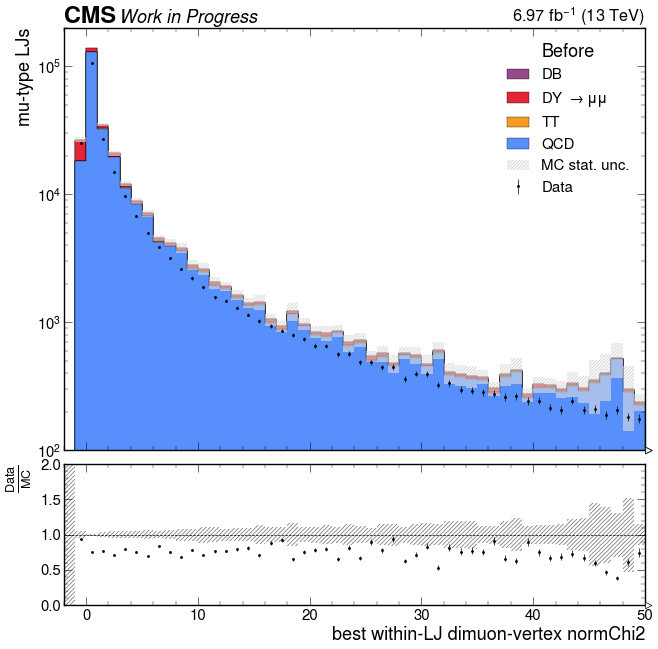

In [4]:
plot_DataMC_channels("mu_lj_vtx_chi2", channels[:1],
                     xlabel="best within-LJ dimuon-vertex normChi2",
                     ylabel="mu-type LJs")

**How to read Figure 2:** the same distribution on a logarithmic normChi2 axis, with the -1
sentinel bin and the near-zero bin dropped so that the axis can be logarithmic; the three
dashed red lines are the candidate thresholds 2, 5 and 10. The no-vertex fractions that the
plot cannot show are printed underneath.

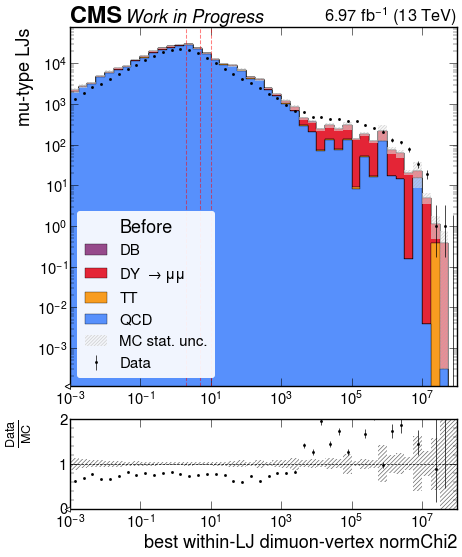

Before channel, mu-type LJs: data 248594, MC 322813
  no-vertex (-1) fraction:  data 0.101   MC 0.083
  0 <= vtx_chi2 < 5 (pass): data 0.676   MC 0.688
  (four histogram bins per decade, so this '5' is really 5.62; the cut in selections.yaml is a true < 5)


In [5]:
def plot_vtx_log(channel_name, label):
    sl = slice(2, None)  # drop the -1 sentinel bin and the [-0.5, 1e-3) bin for the log display
    fig, ax_main, ax_comp = hep.comp.data_model(
        data_hist=sum_data_all["mu_lj_vtx_chi2_log"][channel_name, sl],
        stacked_components=[ratio * s["mu_lj_vtx_chi2_log"][channel_name, sl]
                            for s in summed_MC],
        stacked_labels=MC_LABELS,
        xlabel="best within-LJ dimuon-vertex normChi2",
        ylabel="mu-type LJs",
        data_w2method="poisson",
    )
    hep.cms.label(data=True, lumi=LUMI_DATA, text="Work in Progress", ax=ax_main)
    ax_main.set_xscale("log")
    ax_main.set_yscale("log")
    ax_comp.set_xscale("log")
    for t in (2, 5, 10):
        ax_main.axvline(t, color="red", linestyle="--", alpha=0.5)
    ax_main.legend(title=label, loc="lower left", frameon=True, facecolor="white",
                   edgecolor="none", framealpha=0.92)
    plt.show()
    plt.close()


plot_vtx_log(CR_BEFORE, "Before")

v_data_cr = vtx_log(sum_data_all, CR_BEFORE)
v_mc_cr   = sum(vtx_log(s, CR_BEFORE, ratio) for s in summed_MC)
print(f"Before channel, mu-type LJs: data {v_data_cr.sum():.0f}, MC {v_mc_cr.sum():.0f}")
print(f"  no-vertex (-1) fraction:  data {v_data_cr[1]/v_data_cr.sum():.3f}"
      f"   MC {v_mc_cr[1]/v_mc_cr.sum():.3f}")
print(f"  0 <= vtx_chi2 < 5 (pass): data {kept(v_data_cr, 5)/v_data_cr.sum():.3f}"
      f"   MC {kept(v_mc_cr, 5)/v_mc_cr.sum():.3f}")
print(f"  (four histogram bins per decade, so this '5' is really {edge_for(5):.2f}; the cut "
      f"in selections.yaml is a true < 5)")

### 2b. Cosmic-enriched region

The **spread-inverted cosmic region** (`cosmic_muons`) is the region the Spread veto was
designed against: the Spread cuts are inverted (`inverse_spread`) and the cosAlpha event cut is
inverted, so it selects back-to-back muon pairs with a large spread in impact parameters. It is
*not* the vertex-inverted cosmic region of sections 5 to 7, which is a different selection.
It contains no `vtx_chi2`
requirement at all, which is what makes it a test of the vertex variable rather than a
tautology - the variable is asked to flag objects that were selected using entirely different
quantities.

**How to read Figure 3:** mu-type LJs per bin of the best within-LJ dimuon-vertex normChi2 in
the spread-inverted cosmic region, on a logarithmic axis with the -1 sentinel and near-zero bins
dropped; the printed fractions underneath do include the sentinel bin, which carries almost
all of the region.

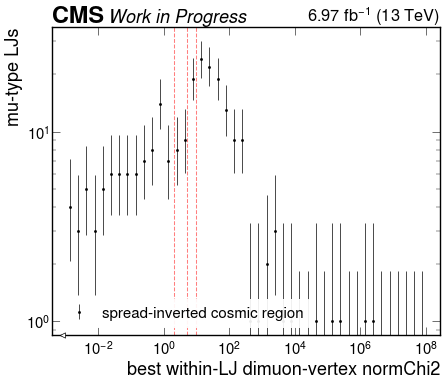

spread-inverted cosmic region (cosmic_muons): 4994 mu-type LJs
  no-vertex (-1) fraction:    0.955
  0 <= vtx_chi2 < 5 (passes): 0.020
  fails 0 <= vtx_chi2 < 5:    0.980
  the same three numbers in the Before channel (data): 0.101 / 0.676 / 0.324


In [6]:
cos_file = f"{sidm_path}/RunOutputFiles/vtxCosmic_2018C/DoubleMuon_2018C.coffea"
H_cos    = coffea.util.load(cos_file)["out"]["DoubleMuon_2018C"]["hists"]
CH_COS   = "cosmic_muons"
assert np.allclose(H_cos["mu_lj_vtx_chi2_log"][CH_COS, :].axes[0].edges, LOG_EDGES)

fig, ax = plt.subplots(figsize=(10, 8))
hep.histplot(H_cos["mu_lj_vtx_chi2_log"][CH_COS, 2:], ax=ax, histtype="errorbar", color="k",
             label="spread-inverted cosmic region")
for t in (2, 5, 10):
    ax.axvline(t, color="red", linestyle="--", alpha=0.5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("best within-LJ dimuon-vertex normChi2")
ax.set_ylabel("mu-type LJs")
ax.legend(loc="lower left", frameon=True, facecolor="white", edgecolor="none",
          framealpha=0.92)
hep.cms.label(data=True, lumi=LUMI_DATA, text="Work in Progress", ax=ax)
plt.show()
plt.close()

v_cos = H_cos["mu_lj_vtx_chi2_log"][CH_COS, :].values(flow=True)
t_cos = v_cos.sum()
print(f"spread-inverted cosmic region ({CH_COS}): {t_cos:.0f} mu-type LJs")
print(f"  no-vertex (-1) fraction:    {v_cos[1]/t_cos:.3f}")
print(f"  0 <= vtx_chi2 < 5 (passes): {kept(v_cos, 5)/t_cos:.3f}")
print(f"  fails 0 <= vtx_chi2 < 5:    {1 - kept(v_cos, 5)/t_cos:.3f}")
print(f"  the same three numbers in the Before channel (data): "
      f"{v_data_cr[1]/v_data_cr.sum():.3f} / {kept(v_data_cr, 5)/v_data_cr.sum():.3f} / "
      f"{1 - kept(v_data_cr, 5)/v_data_cr.sum():.3f}")

The Spread variables of the same region are shown next as a cross-check on what the region
contains. They are large by construction, since `inverse_spread` is one of the cuts that
defines the region; the point of the comparison is that `vtx_chi2`, which is used nowhere in
that definition, independently flags the same objects.

One detail to keep in mind when reading them: `inverse_spread` in `cuts.py` is the OR of
`vzSpread_pf > 10`, `vxySpread_pf > 10` and `vxySpread_mu > 50`, the last term being written
twice, so it is not the exact complement of the four keep-cuts of the Spread channel and in
particular never requires `dzSpread_mu` itself to be large. That is why the fractions printed
below the figure differ between the variables.

**How to read Figure 4:** mu-type LJs per bin of two of the Spread variables in the
spread-inverted cosmic region - the muon longitudinal impact-parameter spread `dzSpread_mu`
(left) and the muon transverse vertex-position spread `vxySpread_mu` (right), both of them
variables the Spread channel cuts on at 50 cm, which is where the dashed line sits.
`dxySpread_mu`, the variable of the `_dxy` channel variant, is printed underneath rather than
plotted, since the two channel variants agree to one part in 4 x 10^4.

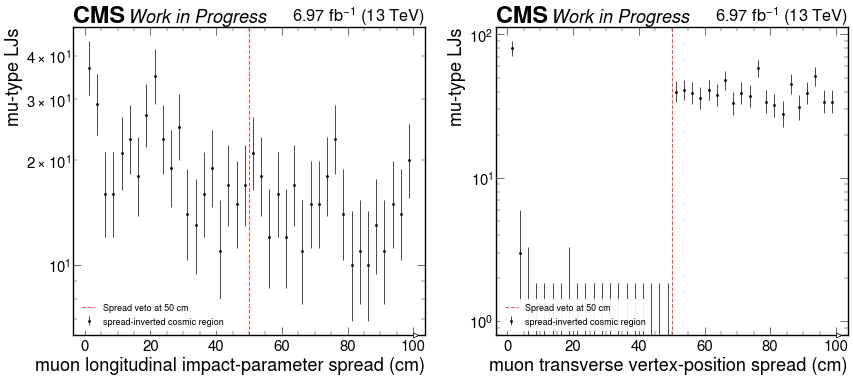

  mu_lj_dzSpread_mu      fraction above 50 cm: 0.419
  mu_lj_dxySpread_mu     fraction above 50 cm: 0.889
  mu_lj_vxySpread_mu     fraction above 50 cm: 0.902


In [7]:
SPREAD_LABEL = {"mu_lj_dzSpread_mu":  "muon longitudinal impact-parameter spread",
                "mu_lj_vxySpread_mu": "muon transverse vertex-position spread",
                "mu_lj_dxySpread_mu": "muon transverse impact-parameter spread"}

# Both panels show a variable the Spread channel actually cuts on at 50 cm: dzSpread_mu and
# vxySpread_mu. dxySpread_mu, the variable of the `_dxy` channel variant, is printed below
# rather than plotted, since the two channels differ by 1 part in 4 x 10^4.
fig, axs = plt.subplots(1, 2, figsize=(20, 8))
for ax, name, cut in ((axs[0], "mu_lj_dzSpread_mu", 50), (axs[1], "mu_lj_vxySpread_mu", 50)):
    hep.histplot(H_cos[name][CH_COS, ::5j], ax=ax, histtype="errorbar", color="k",
                 label="spread-inverted cosmic region")
    ax.axvline(cut, color="red", linestyle="--", alpha=0.7, label=f"Spread veto at {cut} cm")
    ax.set_yscale("log")
    ax.set_xlabel(f"{SPREAD_LABEL[name]} (cm)")
    ax.set_ylabel("mu-type LJs")
    ax.legend(fontsize=13, loc="lower left", frameon=True, facecolor="white",
              edgecolor="none", framealpha=0.92)
    hep.cms.label(data=True, lumi=LUMI_DATA, text="Work in Progress", ax=ax)
plt.show()
plt.close()

for name in ("mu_lj_dzSpread_mu", "mu_lj_dxySpread_mu", "mu_lj_vxySpread_mu"):
    h = H_cos[name][CH_COS, :]
    v, e = h.values(flow=True)[1:-1], h.axes[0].edges[:-1]
    print(f"  {name:22s} fraction above 50 cm: {v[e >= 50].sum()/v.sum():.3f}")

### 2c. Signal

The same per-LJ distribution for the v10 signal samples, in the
`base_ljDisplacementIso_cosAlpha` channel. The cell below makes one pass over the whole grid,
keeping only the per-sample numbers the rest of the notebook needs: the summed lepton-jet and
DSA-muon yields in the four signal channels, the `mu_lj_vtx_chi2_log` profile, the effective
sample size, and the survival of a `sigma(pT)/pT < 0.3` cut. The counting units are defined
once here and used consistently from now on:

- **per LJ** - the summed `mu_lj_pt` yield, i.e. one entry per mu-type lepton jet;
- **per DSA muon** - the summed `mu_lj_dsaMuon_pt_relPtErr` yield, i.e. one entry per DSA muon
  inside a mu-type lepton jet.

The two are not interchangeable and are never mixed inside a single comparison, because a
lepton jet can hold several DSA muons and the vetoes act on the jet.

Signal yields are cross-section weighted, so a sample's statistical weight is its effective
entry count `N_eff = (sum w)^2 / sum w^2` rather than its file count. Samples with
`N_eff < 200` produce efficiencies that land on exactly 1.000 off a handful of entries; the
aggregates below are quoted both over all 180 samples and over the robust subset.

**How to read Figure 5:** shape comparison only - each curve is the fraction of that sample's
mu-type LJs per bin, normalized over the plotted logarithmic bins alone, so the -1 sentinel is
excluded from the normalization and printed separately underneath. Signal curves sitting at
lower normChi2 than the background curve would mean the variable separates signal from
background; overlapping curves mean it does not.

In [8]:
SIG_DIR    = f"{sidm_path}/RunOutputFiles/vtxChi2_signal_2018"
SIG_BASE   = "base_ljDisplacementIso"
SIG_REF    = "base_ljDisplacementIso_cosAlpha"
SIG_SPREAD = "base_ljDisplacementIso_cosAlpha_ljSpread"
SIG_VTX    = "base_ljDisplacementIso_cosAlpha_vtxChi2"
SIG_CHANNELS = [(SIG_BASE, "base"), (SIG_REF, "+ cosAlpha"),
                (SIG_SPREAD, "+ Spread veto"), (SIG_VTX, "+ vertex-fit veto")]
RELPT_CUT = 0.3
NEFF_MIN  = 200

sig_files = sorted(glob.glob(f"{SIG_DIR}/*.coffea"))
sig_names = [os.path.basename(f)[:-len(".coffea")] for f in sig_files]


def parse_sample(name):
    # 4Mu_100GeV_1p2GeV_9p6mm -> ("4Mu", 100.0, 1.2, 9.6); "p" is the decimal point
    fs, m, ma, ct = name.split("_")
    num = lambda s: float(s.replace("GeV", "").replace("mm", "").replace("p", "."))
    return fs, num(m), num(ma), num(ct)


sig_info = {n: parse_sample(n) for n in sig_names}

sig_rows, sig_vtxlog = [], {}
for f, n in zip(sig_files, sig_names):
    H = coffea.util.load(f)["out"][n]["hists"]
    hrp = H["mu_lj_dsaMuon_pt_relPtErr"]
    href = hrp[{"channel": SIG_REF}]
    v, var = href.values(flow=True), href.variances(flow=True)
    ye = href.axes[1].edges
    good = np.concatenate(([False], ye[:-1] < RELPT_CUT, [False]))   # y-flow-aware mask
    dsa = {ch: float(hrp[{"channel": ch}].values(flow=True).sum())
           for ch, _ in SIG_CHANNELS}
    lj = {ch: float(H["mu_lj_pt"][{"channel": ch}].values(flow=True).sum())
          for ch, _ in SIG_CHANNELS}
    sig_vtxlog[n] = H["mu_lj_vtx_chi2_log"][{"channel": SIG_REF}].values(flow=True)
    fs, m, ma, ct = sig_info[n]
    sig_rows.append(dict(
        name=n, fs=fs, m=m, ma=ma, ct=ct,
        neff=float(v.sum() ** 2 / var.sum()),
        dsa_ref=dsa[SIG_REF], lj_ref=lj[SIG_REF],
        dsa_sp=dsa[SIG_SPREAD] / dsa[SIG_REF], dsa_vt=dsa[SIG_VTX] / dsa[SIG_REF],
        lj_sp=lj[SIG_SPREAD] / lj[SIG_REF], lj_vt=lj[SIG_VTX] / lj[SIG_REF],
        surv=float(v[:, good].sum() / v.sum()),
        surv_and=float(hrp[{"channel": SIG_SPREAD}].values(flow=True)[:, good].sum()
                       / v.sum()),
    ))

SKEYS = ("m", "ma", "ct", "neff", "dsa_ref", "lj_ref", "dsa_sp", "dsa_vt",
         "lj_sp", "lj_vt", "surv", "surv_and")
S      = {k: np.array([r[k] for r in sig_rows], float) for k in SKEYS}
SNAME  = np.array([r["name"] for r in sig_rows])
SFS    = np.array([r["fs"] for r in sig_rows])
robust = S["neff"] >= NEFF_MIN
WSIG   = S["dsa_ref"]

print(f"{len(sig_names)} signal samples in {os.path.basename(SIG_DIR)}")
print(f"  final states     : "
      + ", ".join(f"{u} {int((SFS == u).sum())}" for u in sorted(set(SFS.tolist()))))
print(f"  mediator masses  : {sorted(set(S['m'].tolist()))}")
print(f"  dark-photon mass : {sorted(set(S['ma'].tolist()))}")
print(f"  ctau values      : {len(set(S['ct'].tolist()))} spanning "
      f"{S['ct'].min():g} - {S['ct'].max():g} mm")
print(f"  N_eff percentiles 0/5/50/95/100: "
      + " ".join(f"{x:.0f}" for x in np.percentile(S["neff"], [0, 5, 50, 95, 100])))
print(f"  samples with N_eff < {NEFF_MIN} (efficiencies there are noise): "
      f"{int((~robust).sum())} of {len(sig_names)}")

180 signal samples in vtxChi2_signal_2018
  final states     : 2Mu2E 90, 4Mu 90
  mediator masses  : [100.0, 150.0, 200.0, 500.0, 800.0, 1000.0]
  dark-photon mass : [0.25, 1.2, 5.0]
  ctau values      : 64 spanning 0.002 - 400 mm
  N_eff percentiles 0/5/50/95/100: 3 61 7487 94197 163055
  samples with N_eff < 200 (efficiencies there are noise): 18 of 180


benchmarks used in the shape overlay: ['2Mu2E_100GeV_0p25GeV_20p0mm', '2Mu2E_800GeV_0p25GeV_2p5mm', '4Mu_150GeV_5p0GeV_270p0mm', '4Mu_1000GeV_5p0GeV_40p0mm']


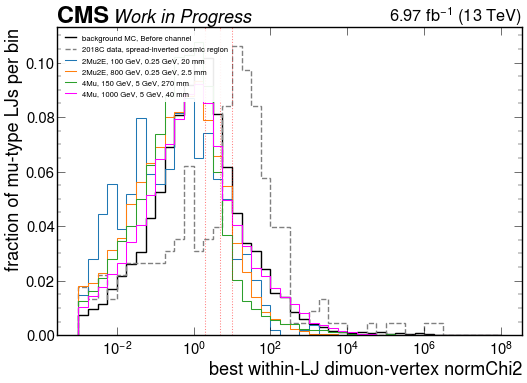

no-vertex (-1) fraction, excluded from the normalization above:
  background MC, Before channel                  0.083
  2018C data, spread-inverted cosmic region      0.955
  2Mu2E, 100 GeV, 0.25 GeV, 20 mm                0.200
  2Mu2E, 800 GeV, 0.25 GeV, 2.5 mm               0.423
  4Mu, 150 GeV, 5 GeV, 270 mm                    0.080
  4Mu, 1000 GeV, 5 GeV, 40 mm                    0.130


In [9]:
def shape(vals):
    # fraction per bin over the 44 logarithmic bins (flow indices 3 .. -2)
    log_bins = vals[3:-1]
    return log_bins / log_bins.sum() if log_bins.sum() > 0 else log_bins


log_edges_plot = LOG_EDGES[2:]   # the edges of the 44 logarithmic bins

# four benchmarks spanning the grid: the longest lifetime of four evenly spaced
# (final state, mediator mass, dark-photon mass) families, that being where the muons are
# most displaced and the vertex fit is most stressed
families = {}
for n in sig_names:
    fs, m, ma, ct = sig_info[n]
    families.setdefault((fs, m, ma), []).append(n)
for k in families:
    families[k].sort(key=lambda n: sig_info[n][3])
fam_keys = sorted(families)
idx = np.linspace(0, len(fam_keys) - 1, 4).round().astype(int)
benchmarks = [families[fam_keys[i]][-1] for i in dict.fromkeys(idx.tolist())]
print("benchmarks used in the shape overlay:", benchmarks)

fig, ax = plt.subplots(figsize=(12, 8))
hep.histplot(shape(v_mc_cr), log_edges_plot, ax=ax, histtype="step", linewidth=2,
             color="k", label="background MC, Before channel")
hep.histplot(shape(v_cos), log_edges_plot, ax=ax, histtype="step", linewidth=2,
             color="grey", linestyle="--", label="2018C data, spread-inverted cosmic region")
no_vtx = {"background MC, Before channel": v_mc_cr[1]/v_mc_cr.sum(),
          "2018C data, spread-inverted cosmic region": v_cos[1]/v_cos.sum()}
for n, sc in zip(benchmarks, ["tab:blue", "tab:orange", "tab:green", "magenta"]):
    v = sig_vtxlog[n]
    fs, m, ma, ct = sig_info[n]
    lab = f"{fs}, {m:.0f} GeV, {ma:g} GeV, {ct:g} mm"
    hep.histplot(shape(v), log_edges_plot, ax=ax, histtype="step", color=sc, label=lab)
    no_vtx[lab] = v[1]/v.sum()
for t in (2, 5, 10):
    ax.axvline(t, color="red", linestyle=":", alpha=0.5)
ax.set_xscale("log")
ax.set_xlabel("best within-LJ dimuon-vertex normChi2")
ax.set_ylabel("fraction of mu-type LJs per bin")
ax.legend(fontsize=11, loc="upper left", frameon=True, facecolor="white", edgecolor="none",
          framealpha=0.92)
hep.cms.label(data=True, lumi=LUMI_DATA, text="Work in Progress", ax=ax)
plt.show()
plt.close()

print("no-vertex (-1) fraction, excluded from the normalization above:")
for k, v in no_vtx.items():
    print(f"  {k:46s} {v:.3f}")

## 3. Control-region comparison against the Spread veto

The four panels below are the data/MC comparison of the DSA-muon pT inside the mu-type LJ,
which is where the residual excess at high pT sits. The first two panels are the existing
before/after pair for the Spread veto; the third replaces the four Spread cuts by
`0 <= vtx_chi2 < 5`; the fourth drops the cosAlpha event cut as well, to show how much of the
back-to-back rejection the vertex requirement covers on its own.

**How to read Figure 6:** four data/MC panels on common axes, log scale, MC stacked by process
and scaled by 6.97/59.83; the lower sub-panel of each is the data/MC ratio, and the question
is whether that ratio above 200 GeV comes closer to unity.

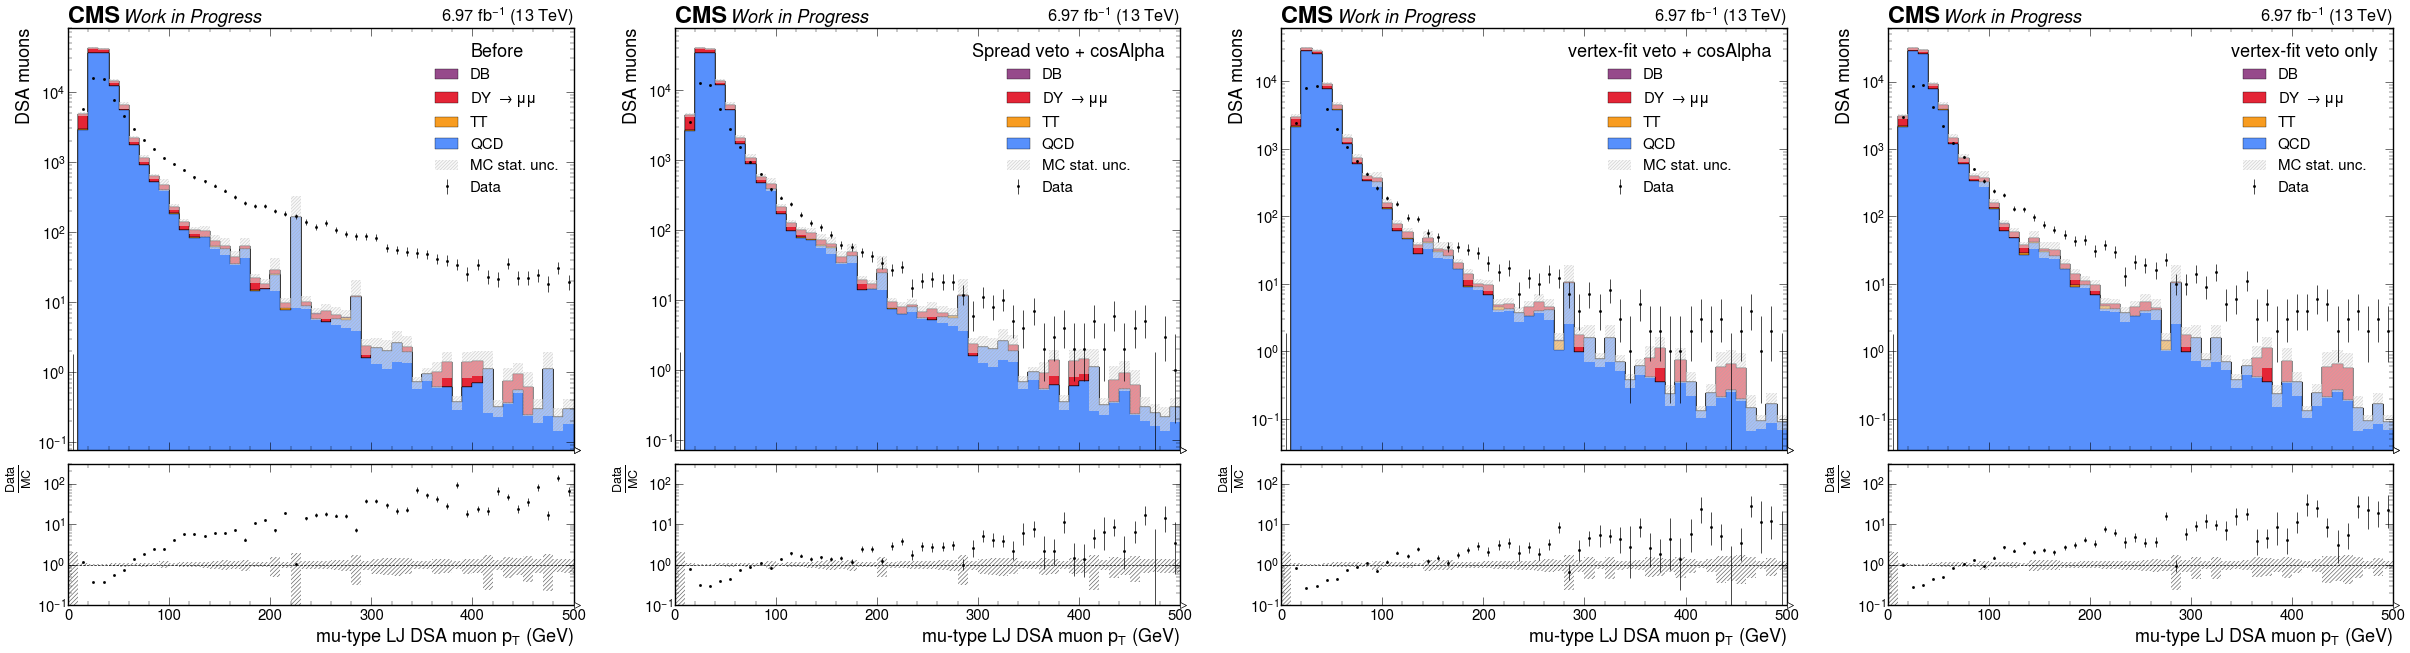

In [10]:
plot_DataMC_channels("mu_lj_dsaMuon_pt", channels, binning=2j,
                     xlabel=r"mu-type LJ DSA muon $p_{T}$ (GeV)",
                     ylabel="DSA muons", ratio_ylim=(0.1, 300))

Yields from the same histogram, overall and above 200 GeV, followed by the MC composition of
the high-pT region.

In [11]:
hname = "mu_lj_dsaMuon_pt"


def tot(summed, channel_name, lo=None, scale=1.0):
    h1 = summed[hname][channel_name, :]
    vals = scale * h1.values(flow=True)
    if lo is None:
        return vals.sum()
    i = np.searchsorted(h1.axes[0].edges, lo) + 1  # +1: index 0 of flow=True is the underflow
    return vals[i:].sum()


print(f"{'channel':28s} {'data':>9s} {'MC':>11s} {'data/MC':>8s} | "
      f"{'data>200':>9s} {'MC>200':>9s} {'d/MC>200':>9s}")
for channel_name, label in channels:
    d     = tot(sum_data_all, channel_name)
    d200  = tot(sum_data_all, channel_name, 200)
    mc    = sum(tot(s, channel_name, scale=ratio)      for s in summed_MC)
    mc200 = sum(tot(s, channel_name, 200, scale=ratio) for s in summed_MC)
    print(f"{label:28s} {d:9.0f} {mc:11.1f} {d/mc:8.2f} | "
          f"{d200:9.0f} {mc200:9.1f} {d200/mc200:9.2f}")

print("\nMC composition above 200 GeV in the Before channel (scaled to 6.97/fb), top 5:")
comp = [(s, tot(utilities.sum_hist([s], dir_name), CR_BEFORE, 200, scale=ratio))
        for s in QCD + TT + DY + DB]
for s, y in sorted(comp, key=lambda r: -r[1])[:5]:
    print(f"  {s:22s} {y:8.1f}")

# The control region is not normalized. Quote the mismatch in both counting units, because
# the two are not the same number and their ratio is the thing that is actually mismodelled.
lj_d, lj_m = v_data_cr.sum(), v_mc_cr.sum()
ds_d = tot(sum_data_all, CR_BEFORE)
ds_m = sum(tot(s, CR_BEFORE, scale=ratio) for s in summed_MC)
print("\nControl-region normalization, Before channel (no scale factor is applied anywhere):")
print(f"  mu-type LJs               : data {lj_d:8.0f}   MC {lj_m:9.1f}   "
      f"data/MC {lj_d/lj_m:.3f}")
print(f"  DSA muons inside them     : data {ds_d:8.0f}   MC {ds_m:9.1f}   "
      f"data/MC {ds_d/ds_m:.3f}")
print(f"  DSA muons per mu-type LJ  : data {ds_d/lj_d:8.3f}   MC {ds_m/lj_m:9.3f}   "
      f"-> MC carries {100*((ds_m/lj_m)/(ds_d/lj_d) - 1):.0f}% more")

channel                           data          MC  data/MC |  data>200    MC>200  d/MC>200
Before                           63040    113357.3     0.56 |      2414     293.6      8.22
Spread veto + cosAlpha           40881    108137.7     0.38 |       309     133.7      2.31
vertex-fit veto + cosAlpha       28303     80040.4     0.35 |       187      78.4      2.38
vertex-fit veto only             30985     80649.5     0.38 |       367      78.8      4.66

MC composition above 200 GeV in the Before channel (scaled to 6.97/fb), top 5:


  QCD_Pt30To50              155.7
  QCD_Pt170To300             29.9
  QCD_Pt300To470             27.6
  QCD_Pt80To120              27.6
  DYJetsToLL_M50             16.6

Control-region normalization, Before channel (no scale factor is applied anywhere):
  mu-type LJs               : data   248594   MC  322813.4   data/MC 0.770
  DSA muons inside them     : data    63040   MC  113357.3   data/MC 0.556
  DSA muons per mu-type LJ  : data    0.254   MC     0.351   -> MC carries 38% more


### 3.1 The control region is not normalized, and what that does and does not affect

The yields above are not close to each other, and the mismatch is not one number. In the
Before channel the region holds 0.770 data mu-type lepton jets per MC one, but only 0.556 data
DSA muons per MC one (63040 against 113357.3). Those are not the same discrepancy seen twice:
their ratio is the DSA-muon *multiplicity*, and MC carries 0.351 DSA muons per mu-type lepton
jet against 0.254 in data - 38% more. So the dominant effect is not an overall cross-section
normalization, which would move both numbers together; it is that simulation puts more
reconstructed DSA muons inside a mu-type lepton jet than data does. No scale factor is applied
anywhere in this study and none is derived here.

What that does and does not touch:

- **It does not touch the veto comparison.** Every efficiency in sections 3 and 4 is a ratio of
  one channel to another *within* data or *within* MC, so a common normalization cancels.
- **It does not touch the cosmic conclusions of section 7.** The azimuthal test is a ratio of
  two bins of the same data distribution.
- **It does inflate every absolute data/MC ratio quoted for the tail**, including the
  2.4 +/- 0.4 residual, by whatever part of the 38% multiplicity mismodelling survives to
  `pT >= 200` GeV. That fraction is not measured here, so the tail data/MC is reported but is
  not the load-bearing number.
- **The tail conclusions are therefore stated as rates wherever possible** - tail entries
  divided by all entries of the same channel and the same collection - which divide the
  mismatch out of numerator and denominator alike. That is exactly the form the closure test
  of section 8 takes, and it is why that test, rather than the raw 2.4, carries the argument.

### 3.2 Scanning the vertex-fit threshold

The threshold of the vertex cut is not fixed by the code, so the next cell scans it. For each
candidate value it reports the fraction of Before-channel mu-type LJs kept in data and in MC,
and the data/MC ratio of what survives: a variable with separating power would drive that
ratio away from its no-cut value as the cut tightens.

**How to read Figure 7:** left panel, the fraction of Before-channel mu-type LJs kept by
`0 <= vtx_chi2 < threshold` in data and in scaled MC, against the threshold on a logarithmic
axis; right panel, the data/MC ratio of the surviving lepton jets with its statistical
uncertainty (data Poisson plus weighted-MC), zoomed to 0.70 - 0.80, with the dashed line at
the same ratio with no cut applied. A flat line means the cut removes data and MC in the same
proportion at every threshold. Two things to hold on to: the abscissa is the *actual* bin edge
used, not the requested value (the histogram has four bins per decade, so a requested 5 is
5.62 and a requested 2 is 3.16), and the nine points are nested selections of one sample, so
they are strongly correlated and are not nine independent measurements.

 requested  edge used  data kept   MC kept      data/MC of kept
         2       3.16      0.605     0.616         0.756 +/- 0.010
         5       5.62      0.676     0.688         0.757 +/- 0.009
        10      10.00      0.731     0.743         0.757 +/- 0.009
        30      31.62      0.801     0.814         0.758 +/- 0.008
       100     100.00      0.839     0.863         0.749 +/- 0.008
       300     316.23      0.863     0.889         0.747 +/- 0.008
      1000    1000.00      0.875     0.902         0.747 +/- 0.008
      3000    3162.28      0.882     0.909         0.747 +/- 0.008
     10000   10000.00      0.886     0.911         0.749 +/- 0.008

Before-channel totals: data 248594, MC 322813, data/MC with no cut 0.770
The nine points are nested selections of the same sample and so are strongly
correlated; the error bars are per-point and are not nine independent measurements.


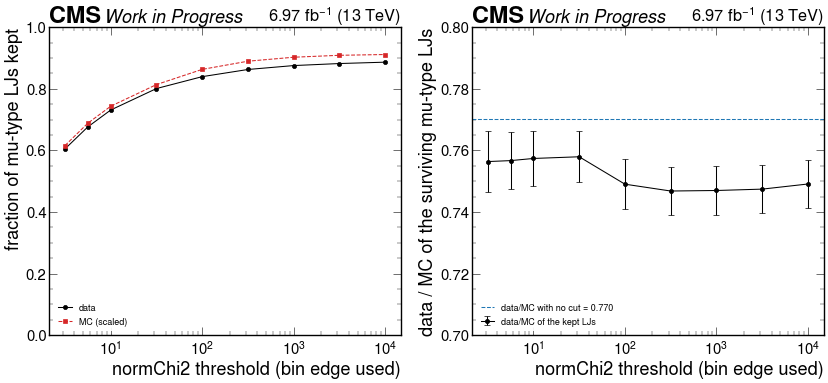

In [12]:
thresholds = np.array([2, 5, 10, 30, 100, 300, 1000, 3000, 10000], dtype=float)
edges_used = np.array([edge_for(t) for t in thresholds])
tot_d, tot_m = v_data_cr.sum(), v_mc_cr.sum()
var_mc_cr = sum(vtx_log_var(s, CR_BEFORE, ratio) for s in summed_MC)
n_kept_d = np.array([kept(v_data_cr, t) for t in thresholds])
n_kept_m = np.array([kept(v_mc_cr, t) for t in thresholds])
n_kept_mv = np.array([kept(var_mc_cr, t) for t in thresholds])
kf_d, kf_m = n_kept_d / tot_d, n_kept_m / tot_m
dmc_kept = n_kept_d / n_kept_m
e_dmc = dmc_kept * np.sqrt(1 / n_kept_d + n_kept_mv / n_kept_m ** 2)

print(f"{'requested':>10s} {'edge used':>10s} {'data kept':>10s} {'MC kept':>9s} "
      f"{'data/MC of kept':>20s}")
for t, ee, a, b, r, er in zip(thresholds, edges_used, kf_d, kf_m, dmc_kept, e_dmc):
    print(f"{t:10.0f} {ee:10.2f} {a:10.3f} {b:9.3f} {r:13.3f} +/-{er:6.3f}")
print(f"\nBefore-channel totals: data {tot_d:.0f}, MC {tot_m:.0f}, "
      f"data/MC with no cut {tot_d/tot_m:.3f}")
print("The nine points are nested selections of the same sample and so are strongly")
print("correlated; the error bars are per-point and are not nine independent measurements.")

fig, axs = plt.subplots(1, 2, figsize=(20, 8))
axs[0].plot(edges_used, kf_d, "o-", color="k", label="data")
axs[0].plot(edges_used, kf_m, "s--", color="tab:red", label="MC (scaled)")
axs[0].set_ylabel("fraction of mu-type LJs kept")
axs[0].set_ylim(0, 1)
axs[1].errorbar(edges_used, dmc_kept, yerr=e_dmc, fmt="o-", color="k", capsize=4,
                label="data/MC of the kept LJs")
axs[1].axhline(tot_d/tot_m, color="tab:blue", linestyle="--",
               label=f"data/MC with no cut = {tot_d/tot_m:.3f}")
axs[1].set_ylabel("data / MC of the surviving mu-type LJs")
axs[1].set_ylim(0.70, 0.80)
for ax in axs:
    ax.set_xscale("log")
    ax.set_xlabel("normChi2 threshold (bin edge used)")
    ax.legend(fontsize=13, loc="lower left", frameon=True, facecolor="white",
              edgecolor="none", framealpha=0.92)
    hep.cms.label(data=True, lumi=LUMI_DATA, text="Work in Progress", ax=ax)
plt.show()
plt.close()

The vertex veto is the tighter cut: on its own it keeps 49% of the Before-channel DSA-muon
entries, against 65% for the four Spread cuts together with the cosAlpha event cut, and at the
scan's "5" - really the bin edge at 5.62, since the histogram carries four bins per decade and
a requested threshold snaps up to the nearest edge - it keeps 68% of the control region's
mu-type LJs, the threshold sitting on the peak of the distribution. The selection itself cuts
at a true `vtx_chi2 < 5`; only this scan snaps, and the two differ by well under a bin.

It is not, however, the better discriminant. Above 200 GeV it leaves 187 data against 78 MC
entries, a ratio of 2.38, against 309 / 134 and a ratio of 2.31 for the Spread veto - both on
the **full background stack**: the same residual within its uncertainty, on a smaller sample.
(The eight-sample tail MC set introduced in section 5 gives 2.385 +/- 0.426 for the Spread
veto, consistent with the 2.31 here; section 5 shows why the two MC sets differ before the veto
and agree after it.) The data/MC ratio of the surviving mu-type LJs is flat at 0.75 across the
whole scanned range, against 0.77 with no cut at all - the nine scan points are nested and
therefore correlated, but their spread is far smaller than the step down from 0.77 - so the
variable removes data and MC in the same proportion everywhere, and the no-vertex fractions
differ only slightly (10.1% in data against 8.3% in MC). The residual high-pT excess is
therefore not a population of muon pairs with bad or missing common vertices.

What does help is the cosAlpha event cut. The last two panels differ only by that cut, and it
takes the data above 200 GeV from 367 to 187 while the MC there goes from 79 to 78: it removes
back-to-back pairs that the MC does not have, which is the expected behavior of a cosmic veto.
The MC above 200 GeV is dominated by a handful of high-weight `QCD_Pt30To50` events, so its
uncertainty there is much larger than the statistical error bars suggest.

## 4. Signal efficiency over the full 180-sample grid

The cost of the two vetoes on signal. In all three signal channels the veto is a post-LJ
object cut, so it removes lepton jets and not events: the event-level cutflow is identical
across `base_ljDisplacementIso_cosAlpha`, `..._ljSpread` and `..._vtxChi2`, and the meaningful
efficiency is the ratio of object yields with `base_ljDisplacementIso_cosAlpha` as the
reference. Both counting units of section 2c are reported; **they are never compared with each
other**, only within a unit.

The grid is complete: 180 samples (90 4Mu, 90 2Mu2E), six mediator masses, three dark-photon
masses and 64 distinct proper decay lengths.

In [13]:
def agg(key, mask=None):
    x = S[key] if mask is None else S[key][mask]
    w = WSIG if mask is None else WSIG[mask]
    return dict(n=x.size, mean=x.mean(), median=np.median(x), lo=x.min(), hi=x.max(),
                wmean=(x * w).sum() / w.sum())


def line(d):
    return (f"n={d['n']:3d}  mean {d['mean']:.4f}  median {d['median']:.4f}  "
            f"[{d['lo']:.3f}, {d['hi']:.3f}]  yield-wtd {d['wmean']:.4f}")


print("Veto efficiency relative to the '+ cosAlpha' reference channel.")
print("'yield-wtd' weights each sample by its DSA-muon yield in that reference channel.\n")
for key, lab in (("lj_sp", "Spread veto,     per LJ      "),
                 ("lj_vt", "vtx_chi2 < 5,    per LJ      "),
                 ("dsa_sp", "Spread veto,     per DSA muon"),
                 ("dsa_vt", "vtx_chi2 < 5,    per DSA muon")):
    print(f"{lab}  all 180   : {line(agg(key))}")
    print(f"{' ' * len(lab)}  N_eff>=200: {line(agg(key, robust))}")

print("\nPooling the objects themselves over the whole grid (sum over samples of the "
      "numerator\ndivided by sum of the denominator), per LJ:")
print(f"  Spread veto   {(S['lj_sp'] * S['lj_ref']).sum() / S['lj_ref'].sum():.4f}")
print(f"  vtx_chi2 < 5  {(S['lj_vt'] * S['lj_ref']).sum() / S['lj_ref'].sum():.4f}")

print(f"\nThe vertex veto is the more costly of the two on "
      f"{int((S['lj_vt'] < S['lj_sp']).sum())} of {len(sig_names)} samples per LJ, and on "
      f"{int((S['dsa_vt'] < S['dsa_sp']).sum())} of {len(sig_names)} per DSA muon.")

Veto efficiency relative to the '+ cosAlpha' reference channel.
'yield-wtd' weights each sample by its DSA-muon yield in that reference channel.

Spread veto,     per LJ        all 180   : n=180  mean 0.9634  median 0.9765  [0.670, 1.000]  yield-wtd 0.9520
                               N_eff>=200: n=162  mean 0.9608  median 0.9759  [0.670, 0.993]  yield-wtd 0.9520
vtx_chi2 < 5,    per LJ        all 180   : n=180  mean 0.7060  median 0.7099  [0.484, 0.917]  yield-wtd 0.6402
                               N_eff>=200: n=162  mean 0.6897  median 0.6957  [0.484, 0.903]  yield-wtd 0.6401
Spread veto,     per DSA muon  all 180   : n=180  mean 0.9498  median 0.9701  [0.635, 1.000]  yield-wtd 0.9505
                               N_eff>=200: n=162  mean 0.9495  median 0.9700  [0.635, 0.986]  yield-wtd 0.9505
vtx_chi2 < 5,    per DSA muon  all 180   : n=180  mean 0.6218  median 0.6251  [0.399, 1.000]  yield-wtd 0.5959
                               N_eff>=200: n=162  mean 0.6075  median 0.5923 

The two vetoes are far apart on signal: per lepton jet the Spread veto keeps 0.961 of the
reference sample averaged over the 162 robust points (0.952 weighting each sample by its
DSA-muon yield), against 0.690 for the vertex veto (0.640 yield-weighted). Swapping one for
the other therefore costs roughly 30% of the signal lepton jets, uniformly enough across the
grid that no corner of parameter space repays it - with the single exception isolated below.

The next cell breaks that down along the three grid axes.

**How to read Figure 8:** per-LJ efficiency of the two vetoes averaged over the robust samples
in each group, against mediator mass (left), dark-photon mass (middle) and proper decay length
(right); circles and the solid line are the Spread veto, squares and the dashed line the
vertex veto at a threshold of 5. Error bars are the standard error on each group mean, i.e.
the spread of the samples in that group, not a per-sample statistical error. The vertical gap between the two curves is the signal cost of
swapping one veto for the other, and it narrows to nothing only at the right-hand end of the
ctau panel.


per-LJ efficiency by mediator mass (GeV) (robust subset, unweighted mean over samples,
errors are the standard error on that mean):
         group    n           Spread       vertex fit
           100   22     0.899 +/-0.023     0.748 +/-0.017
           150   27     0.948 +/-0.011     0.759 +/-0.021
           200   26     0.961 +/-0.007     0.737 +/-0.022
           500   29     0.979 +/-0.002     0.670 +/-0.020
           800   29     0.981 +/-0.001     0.631 +/-0.017
          1000   29     0.981 +/-0.001     0.618 +/-0.015

per-LJ efficiency by dark-photon mass m_Zd (GeV) (robust subset, unweighted mean over samples,
errors are the standard error on that mean):
         group    n           Spread       vertex fit
          0.25   57     0.976 +/-0.001     0.627 +/-0.015
           1.2   55     0.975 +/-0.002     0.687 +/-0.013
             5   50     0.927 +/-0.012     0.764 +/-0.010

per-LJ efficiency by proper decay length ctau (mm) (robust subset, unweighted mean over samples

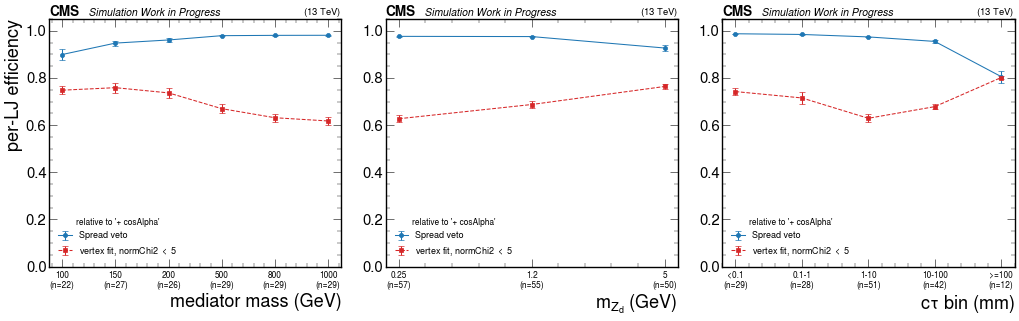

In [14]:
CT_BINS = [(0, 0.1, "<0.1"), (0.1, 1, "0.1-1"), (1, 10, "1-10"),
           (10, 100, "10-100"), (100, 1e9, ">=100")]


def group_means(values, groups, mask):
    """Per-group unweighted mean of each value array, each followed by its standard error.

    The uncertainty is the spread of the samples in the group divided by sqrt(n): it says how
    well the group mean is determined by the points in it, not the statistical error of any
    one sample. Groups of one get 0.
    """
    out = []
    for lab, sel in groups:
        m = mask & sel
        if m.sum():
            stats = []
            for v in values:
                x = v[m]
                stats += [float(x.mean()),
                          float(x.std(ddof=1) / math.sqrt(x.size)) if x.size > 1 else 0.0]
            out.append((lab, int(m.sum()), *stats))
    return out


mass_groups = [(f"{u:.0f}", S["m"] == u) for u in sorted(set(S["m"].tolist()))]
mzd_groups  = [(f"{u:g}", S["ma"] == u) for u in sorted(set(S["ma"].tolist()))]
ct_groups   = [(lab, (S["ct"] >= a) & (S["ct"] < b)) for a, b, lab in CT_BINS]

for title, groups, unit in (("mediator mass (GeV)", mass_groups, ""),
                            ("dark-photon mass m_Zd (GeV)", mzd_groups, ""),
                            ("proper decay length ctau (mm)", ct_groups, "")):
    print(f"\nper-LJ efficiency by {title} (robust subset, unweighted mean over samples,")
    print("errors are the standard error on that mean):")
    print(f"    {'group':>10s} {'n':>4s} {'Spread':>16s} {'vertex fit':>16s}")
    for lab, n, a, ea, b, eb in group_means([S["lj_sp"], S["lj_vt"]], groups, robust):
        print(f"    {lab:>10s} {n:4d} {a:9.3f} +/-{ea:5.3f} {b:9.3f} +/-{eb:5.3f}")

fig, axs = plt.subplots(1, 3, figsize=(21, 7))
for ax, (title, groups, xlab) in zip(axs, (
        ("mediator mass", mass_groups, "mediator mass (GeV)"),
        ("dark-photon mass", mzd_groups, r"$m_{Z_d}$ (GeV)"),
        ("proper decay length", ct_groups, r"$c\tau$ bin (mm)"))):
    rows = group_means([S["lj_sp"], S["lj_vt"]], groups, robust)
    x = np.arange(len(rows))
    ax.errorbar(x, [r[2] for r in rows], yerr=[r[3] for r in rows], fmt="o-",
                color="tab:blue", capsize=4, label="Spread veto")
    ax.errorbar(x, [r[4] for r in rows], yerr=[r[5] for r in rows], fmt="s--",
                color="tab:red", capsize=4, label=r"vertex fit, normChi2 $<$ 5")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{r[0]}\n(n={r[1]})" for r in rows], fontsize=12)
    ax.set_xlabel(xlab)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=13, loc="lower left", title="relative to '+ cosAlpha'",
              title_fontsize=12)
axs[0].set_ylabel("per-LJ efficiency")
for ax in axs.ravel():
    # fontsize 15: the default collides with the "(13 TeV)" stamp in a 7-inch panel
    hep.cms.label(data=False, text="Work in Progress", ax=ax, fontsize=15)
plt.tight_layout()
plt.show()
plt.close()

The trends are consistent between the two counting units and easy to read physically. The
Spread veto costs almost nothing except at long lifetime and large `m_Zd`, where genuinely
displaced, wide muon pairs start to look like the cosmic topology it rejects. The vertex veto
costs 25-40% everywhere and gets *worse* with mediator mass, because a heavy mediator gives
boosted, collimated lepton jets whose muons the Kalman fit pairs less cleanly.

That leaves one corner where the ordering reverses.

**How to read Figure 9:** one point per signal sample, the vertex-veto efficiency against the
Spread-veto efficiency, both per LJ and both relative to `+ cosAlpha`; colour is the
dark-photon mass. Points below the diagonal are samples where the vertex veto is the harsher
cut, which is almost all of them; points above it are the corner discussed below.

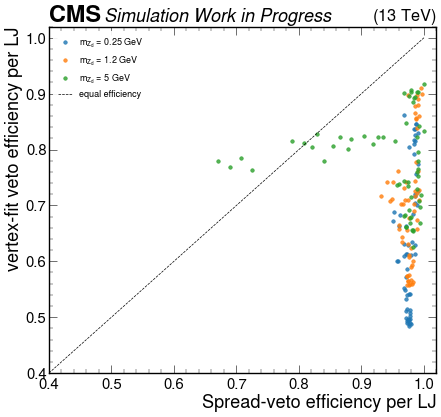


samples where the vertex veto keeps MORE than the Spread veto, per DSA muon: 8 of 180 (8 of them in the robust subset)
  sample                               m_Zd       M      ctau    N_eff   Spread      vtx
  4Mu_100GeV_5p0GeV_400mm                 5     100       400     8396    0.635    0.801
  4Mu_100GeV_5p0GeV_200mm                 5     100       200    12891    0.678    0.809
  2Mu2E_100GeV_5p0GeV_400mm               5     100       400      981    0.666    0.791
  2Mu2E_100GeV_5p0GeV_200mm               5     100       200     1466    0.688    0.793
  4Mu_150GeV_5p0GeV_270p0mm               5     150       270    25849    0.765    0.845
  2Mu2E_150GeV_5p0GeV_270p0mm             5     150       270     4853    0.800    0.850
  4Mu_150GeV_5p0GeV_130p0mm               5     150       130    49154    0.802    0.835
  2Mu2E_150GeV_5p0GeV_130p0mm             5     150       130     6789    0.840    0.849

samples where the vertex veto keeps MORE than the Spread veto, per LJ: 6 of 18

In [15]:
fig, ax = plt.subplots(figsize=(10, 9))
for u, c in zip(sorted(set(S["ma"].tolist())), ["tab:blue", "tab:orange", "tab:green"]):
    m = S["ma"] == u
    ax.scatter(S["lj_sp"][m], S["lj_vt"][m], s=26, color=c, alpha=0.8,
               label=rf"$m_{{Z_d}}$ = {u:g} GeV")
ax.plot([0.4, 1.0], [0.4, 1.0], "k--", linewidth=1, label="equal efficiency")
ax.set_xlabel("Spread-veto efficiency per LJ")
ax.set_ylabel("vertex-fit veto efficiency per LJ")
ax.set_xlim(0.4, 1.02)
ax.set_ylim(0.4, 1.02)
ax.legend(fontsize=13, loc="upper left", frameon=True, facecolor="white", edgecolor="none",
          framealpha=0.92)
hep.cms.label(data=False, text="Work in Progress", ax=ax)
plt.show()
plt.close()

for unit, sp, vt in (("per DSA muon", "dsa_sp", "dsa_vt"), ("per LJ", "lj_sp", "lj_vt")):
    win = S[vt] > S[sp]
    print(f"\nsamples where the vertex veto keeps MORE than the Spread veto, {unit}: "
          f"{int(win.sum())} of {len(sig_names)} "
          f"({int((win & robust).sum())} of them in the robust subset)")
    print(f"  {'sample':34s} {'m_Zd':>6s} {'M':>7s} {'ctau':>9s} {'N_eff':>8s} "
          f"{'Spread':>8s} {'vtx':>8s}")
    for i in np.argsort(-(S[vt] - S[sp]))[:int(win.sum())]:
        print(f"  {SNAME[i]:34s} {S['ma'][i]:6g} {S['m'][i]:7.0f} {S['ct'][i]:9g} "
              f"{S['neff'][i]:8.0f} {S[sp][i]:8.3f} {S[vt][i]:8.3f}")

The corner is narrow and the two counting units disagree on its exact membership, so it has to
be quoted with the unit attached.

**Per DSA muon it is exactly 8 samples**, and they are perfectly regular: all have
`m_Zd = 5` GeV, a mediator mass of 100 or 150 GeV, and `ctau >= 130` mm - both final states,
four mass-lifetime points each. Every one of them is in the robust subset.

**Per LJ it is 6 samples**, and the set is not the same one: the two 150 GeV / 130 mm points
drop out and `4Mu_100GeV_5p0GeV_40p0mm`, at `ctau = 40` mm, comes in - so the clean
"`ctau >= 130` mm" statement holds only per DSA muon. The margins are small either way
(the largest per-LJ gap is 0.11).

The physics is the min-versus-max asymmetry of section 1: at long lifetime with a heavy dark
photon the muon pairs are widely separated, the Spread variables - a maximum over pairs -
start failing, while `vtx_chi2` - a minimum - still finds one good dimuon. This is the only
region where the vertex fit adds anything, and it is worth remembering if the analysis ever
targets it specifically. It does not justify swapping the veto globally.

## 5. The tail sample: definitions and anchors

Everything from here on concerns the DSA muons inside mu-type lepton jets above 200 GeV, and
uses a second pair of productions that carry the two-dimensional histograms the localization
needs: `vtxTail2_2018C` for data and `vtxTailMC2_2018` for MC.

Two definitions, fixed once and used throughout:

- **tail** = DSA-muon `pT >= 200` GeV, **including the pT overflow row** (`pT > 500` GeV),
  which is real and is where the badly measured muons pile up;
- **bulk** = the low-pT reference. Two versions appear, and each is labelled where it is used:
  `pT < 100` GeV for the localization of section 6, and `pT < 200` GeV - the exact complement
  of the tail - for the cut-cost accounting of section 9.

**The MC here is not the full stack.** `vtxTailMC2_2018` holds only the eight samples that
populate the tail: `DYJetsToLL_M50` and the seven `QCD_Pt` bins from 80 to 1000. Two
consequences, both checked in the cell below rather than assumed:

- **After the veto they carry 97% of the MC tail**, so the post-veto tail data/MC quoted from
  here (2.385 +/- 0.426) is compatible with the full-stack 2.31 of section 3. **Before** the
  veto they carry only 46% of it, because the full stack's pre-veto tail contains one
  `QCD_Pt30To50` event worth about 156 weighted entries which the veto removes. Every pre-veto
  MC tail number below is therefore quoted for this eight-sample set specifically. The
  corollary is worth stating once, because it is easy to quote the wrong half: the veto removes
  **54.5% of the full stack's** pre-veto MC tail (293.6 -> 133.7 weighted entries) and **3% of
  this eight-sample set's** (133.7 -> 129.5). Both are correct and they describe different
  sets. That the eight-sample set's pre-veto tail, 133.7, happens to equal the full stack's
  post-veto tail, also 133.7, is a numerical coincidence of two unrelated quantities.
- They do **not** cover the bulk. Over all pT they carry 52.8% of the full stack's MC yield in
  this channel (57091.1 against 108137.7), the missing half being the soft-QCD bins that
  populate the low-pT region. So absolute data/MC in the bulk is meaningless with this set, and
  so is anything built from its **total** yield - an overall normalization ratio, for instance.
  Only shapes across bins are used there, and section 8 marks the one place where that
  restriction bites.

The cell below also reproduces the section-3 data anchors from these files as a cross-check
that the two productions describe the same selection.

In [16]:
TAIL_FILE = f"{sidm_path}/RunOutputFiles/vtxTail2_2018C/DoubleMuon_2018C.coffea"
MCT_DIR   = f"{sidm_path}/RunOutputFiles/vtxTailMC2_2018"
H_tail    = coffea.util.load(TAIL_FILE)["out"]["DoubleMuon_2018C"]["hists"]
mc_tail   = {os.path.basename(f)[:-len(".coffea")]:
             coffea.util.load(f)["out"][os.path.basename(f)[:-len(".coffea")]]["hists"]
             for f in sorted(glob.glob(f"{MCT_DIR}/*.coffea"))}

CH_BEFORE = "cr_1egmOr1mu_lj"
CH_SPREAD = "cr_1egmOr1mu_lj_spreadMu_spreadPfMu_CosMu"
CH_VTX    = "cr_1egmOr1mu_lj_vtxChi2_CosMu"
CH_COSMIC = "cosmic_muons_vtxChi2"
TAIL_CHANS = [("Before", CH_BEFORE), ("Spread+cosAlpha", CH_SPREAD),
              ("vertex-fit+cosAlpha", CH_VTX), ("vertex-inverted cosmic", CH_COSMIC)]
print("MC samples carrying the tail:", sorted(mc_tail))


def dview(name, ch):
    """Data (values, variances) with flow. Data is unweighted, so Var = N."""
    v = H_tail[name][{"channel": ch}].values(flow=True).astype(float)
    return v, v.copy()


def mview(name, ch):
    """Lumi-scaled MC sum (values, variances) with flow, over the tail samples."""
    tv = te = None
    for H in mc_tail.values():
        if ch not in list(H[name].axes["channel"]):
            continue
        hh = H[name][{"channel": ch}]
        v, e = hh.values(flow=True).astype(float), hh.variances(flow=True).astype(float)
        tv = v.copy() if tv is None else tv + v
        te = e.copy() if te is None else te + e
    return ratio * tv, ratio ** 2 * te


def pt_rows(edges, region):
    """Row indices (flow included) of a pT region of a 2D (pT, y) histogram."""
    if region == "tail":                       # pT >= 200 incl. the pT overflow row
        return slice(int(np.searchsorted(edges, 200.0)) + 1, None)
    lim = 100.0 if region == "bulk100" else 200.0
    return slice(0, int(np.searchsorted(edges, lim)) + 1)   # incl. the pT underflow row


PT_EDGES = H_tail["mu_lj_dsaMuon_pt_nHits"][{"channel": CH_BEFORE}].axes[0].edges
TAIL, BULK100, BULK200 = (pt_rows(PT_EDGES, r) for r in ("tail", "bulk100", "bulk200"))


def prof(v, rows):
    """Collapse a 2D (pT, y) array over a pT region -> 1D y array, y flow columns kept."""
    return v[rows, :].sum(axis=0)


def ratio_err(d, dvar, m, mvar):
    """data/MC and its 1-sigma error (data Poisson + weighted-MC statistical)."""
    if m <= 0:
        return float("nan"), float("nan")
    r = d / m
    return r, r * math.sqrt((dvar / d ** 2 if d > 0 else 0.0) + mvar / m ** 2)


print(f"\n{'channel':24s} {'data total':>11s} {'data tail':>10s} | "
      f"{'MC total':>12s} {'MC tail':>16s} {'data/MC tail':>16s}")
for lab, ch in TAIL_CHANS:
    dv, _ = dview("mu_lj_dsaMuon_pt_nHits", ch)
    d_tot, d_tail = dv.sum(), prof(dv, TAIL).sum()
    if ch in (CH_BEFORE, CH_SPREAD):
        mv, me = mview("mu_lj_dsaMuon_pt_nHits", ch)
        m_tot, m_tail = mv.sum(), prof(mv, TAIL).sum()
        m_err = math.sqrt(prof(me, TAIL).sum())
        r, er = ratio_err(d_tail, d_tail, m_tail, m_err ** 2)
        print(f"{lab:24s} {d_tot:11.0f} {d_tail:10.0f} | {m_tot:12.1f} "
              f"{m_tail:9.2f} +/-{m_err:5.2f} {r:9.3f} +/-{er:5.3f}")
    else:
        print(f"{lab:24s} {d_tot:11.0f} {d_tail:10.0f} | {'-':>12s} {'-':>16s} {'-':>16s}")
print("\n(The 1D mu_lj_dsaMuon_pt yields of section 3 are reproduced exactly: "
      "63040/2414, 40881/309, 28303/187.)")

print("\nHow much of the full stack of section 3 do the eight samples carry?")
print(f"  {'channel':16s} {'region':10s} {'full stack':>12s} {'eight samples':>14s} "
      f"{'coverage':>9s}")
for ch, clab in ((CH_BEFORE, "Before"), (CH_SPREAD, "Spread+cosAlpha")):
    for rlab, lo in (("pT >= 200", 200), ("all pT", None)):
        full  = sum(tot(s, ch, lo, scale=ratio) for s in summed_MC)
        eight = (prof(mview("mu_lj_dsaMuon_pt_nHits", ch)[0], TAIL).sum() if lo
                 else mview("mu_lj_dsaMuon_pt_nHits", ch)[0].sum())
        print(f"  {clab:16s} {rlab:10s} {full:12.1f} {eight:14.1f} "
              f"{100*eight/full:8.1f}%")
print("  Tail coverage after the veto is 97%, which is why the post-veto tail data/MC of this")
print("  set matches the full stack's. Coverage over ALL pT is only 53%: these eight samples")
print("  are the tail set, not a stack, so their TOTAL yield is not a normalization and")
print("  nothing below divides by it except where section 8 flags the result as indicative.")
print("  The Before-channel tail gap is one high-weight QCD_Pt30To50 event carrying about 156")
print("  weighted entries, which the veto removes.")

MC samples carrying the tail: ['DYJetsToLL_M50', 'QCD_Pt120To170', 'QCD_Pt170To300', 'QCD_Pt300To470', 'QCD_Pt470To600', 'QCD_Pt600To800', 'QCD_Pt800To1000', 'QCD_Pt80To120']

channel                   data total  data tail |     MC total          MC tail     data/MC tail
Before                         63040       2414 |      59982.6    133.66 +/-21.95    18.060 +/-2.988
Spread+cosAlpha                40881        309 |      57091.1    129.54 +/-21.91     2.385 +/-0.426
vertex-fit+cosAlpha            28303        187 |            -                -                -
vertex-inverted cosmic         13781       1336 |            -                -                -

(The 1D mu_lj_dsaMuon_pt yields of section 3 are reproduced exactly: 63040/2414, 40881/309, 28303/187.)

How much of the full stack of section 3 do the eight samples carry?
  channel          region       full stack  eight samples  coverage
  Before           pT >= 200         293.6          133.7     45.5%
  Before           al

## 6. Where the surviving tail sits: hit count and pseudorapidity

The Spread veto with cosAlpha takes the data tail from 2414 to 309 while the MC tail barely
moves, 133.7 to 129.5. The question of this section is whether the residual factor of 2.4 is
spread evenly over the tail or concentrated somewhere, since a concentrated excess is a
candidate for a targeted cut and a flat one is not.

Two handles are available in the 2D histograms: the number of DT + CSC hits on the DSA track,
and `|eta|`. Two quantities are computed for each:

- the plain **data/MC ratio per bin**, whose errors carry both the Poisson data error and the
  weighted-MC statistical error;
- the **shape double ratio** `DR_i = f_data,i / f_MC,i`, the ratio of the *fractions* of each
  sample falling in bin `i`. This removes the overall normalization by construction, so it
  answers "is the excess concentrated?" rather than "is there an excess?". Its error uses a
  multinomial term for the data fraction and a weighted-ratio term for the MC fraction, and
  the chi2 against the flat hypothesis `DR = 1` carries `nbins - 1` degrees of freedom because
  the shared normalization removes one. **Every chi2 quoted in this section is that one**;
  other reasonable definitions of a "shape versus flat" test give different numbers.

Three warnings about that chi2, all of which apply to every one quoted below.

1. **It is diagonal-only.** The bins share a normalization, so the `DR_i` are correlated; the
   sum of `((DR_i - 1)/sigma_i)^2` ignores that. Using `nbins - 1` degrees of freedom corrects
   for the constraint, not for the correlation.
2. **It is definition-dependent by a factor of about four.** On the four fine nHits bins
   [10,15), [15,20), [20,25) and [25,30) of the post-veto tail, three reasonable "shape versus
   flat" statistics give 17.7/3 (per-bin data/MC ratio against its best-fit constant, full
   errors), 39.7/3 (the shape double ratio used here) and 75.3/3 (the same ratio with the data
   error only). Regrouping the bins moves each of them again.
3. **No p-value is quoted anywhere.** With 1 and 2 in force a two-significant-figure tail
   probability would be false precision. The chi2 per degree of freedom, with its definition
   attached, is the statement.

The load-bearing number of this section is therefore not a chi2 at all. It is the tail/bulk
ratio of the double ratios, quoted below with its uncertainty.

The same two quantities are computed in the bulk, and that turns out to be essential.

In [17]:
ETA_GROUPS  = [("|eta| [0,0.9)", 0.0, 0.9), ("|eta| [0.9,1.2)", 0.9, 1.2),
               ("|eta| [1.2,2.4)", 1.2, 2.4)]
# the nHits axis is Regular(12, 0, 60), so 5-wide bins; the DSA ID requires > 12 hits, so
# the [10,15) bin can only hold 13 and 14 and [10,20) is content-identical to [12,20)
NHIT_GROUPS = [("nHits [10,20)", 10, 20), ("nHits [20,30)", 20, 30),
               ("nHits [30,40)", 30, 40), ("nHits [40,60)", 40, 60)]
SPLITS = [("mu_lj_dsaMuon_pt_abseta", ETA_GROUPS, "|eta|"),
          ("mu_lj_dsaMuon_pt_nHits", NHIT_GROUPS, "nHits")]


def y_group(v, yedges, lo, hi):
    """Sum the y bins whose left edge lies in [lo, hi). v keeps its y flow columns."""
    m = (yedges[:-1] >= lo) & (yedges[:-1] < hi)
    return v[1:-1][m].sum()


def split_table(name, groups, ch, rows_sel):
    """Per-bin data, MC and data/MC for one channel and one pT region."""
    yedges = H_tail[name][{"channel": ch}].axes[1].edges
    dv, dvar = (prof(a, rows_sel) for a in dview(name, ch))
    mv, mvar = (prof(a, rows_sel) for a in mview(name, ch))
    assert dv[0] == dv[-1] == 0 and mv[0] == mv[-1] == 0, "y flow is not empty"
    D, Dv, M, Mv = dv[1:-1].sum(), dvar[1:-1].sum(), mv[1:-1].sum(), mvar[1:-1].sum()
    out = []
    for lab, lo, hi in groups:
        d  = y_group(dv, yedges, lo, hi);   dvv = y_group(dvar, yedges, lo, hi)
        m  = y_group(mv, yedges, lo, hi);   mvv = y_group(mvar, yedges, lo, hi)
        out.append((lab, d, dvv, m, mvv))
    return out, (D, Dv, M, Mv)


def shape_dr(rows, totals):
    """DR_i = f_data,i / f_MC,i with multinomial (data) and weighted-ratio (MC) errors."""
    D, _, M, Mv = totals
    out = []
    for lab, d, _, m, mvv in rows:
        fd, fm = d / D, m / M
        var_fd = fd * (1 - fd) / D
        var_fm = ((1 - fm) ** 2 * mvv + fm ** 2 * (Mv - mvv)) / M ** 2
        dr = fd / fm if fm > 0 else float("nan")
        err = dr * math.sqrt(var_fd / fd ** 2 + var_fm / fm ** 2) if fd > 0 else float("nan")
        out.append((lab, fd, fm, dr, err))
    return out


DR = {}
for name, groups, tag in SPLITS:
    for ch, clab in ((CH_BEFORE, "Before"), (CH_SPREAD, "Spread+cosAlpha")):
        rows_t, tot_t = split_table(name, groups, ch, TAIL)
        rows_b, tot_b = split_table(name, groups, ch, BULK100)
        r0, e0 = ratio_err(tot_t[0], tot_t[1], tot_t[2], tot_t[3])
        print(f"\n[{tag} | {clab}]  tail: data {tot_t[0]:.0f}  "
              f"MC {tot_t[2]:.2f} +/- {math.sqrt(tot_t[3]):.2f}  ->  data/MC {r0:.3f} +/- {e0:.3f}")
        print(f"    {'bin':18s} {'data':>7s} {'f_data':>7s} {'MC':>9s} {'f_MC':>6s} "
              f"{'data/MC':>17s} {'DR(tail)':>16s} {'DR(bulk)':>16s} {'tail/bulk':>15s}")
        drt, drb = shape_dr(rows_t, tot_t), shape_dr(rows_b, tot_b)
        for (lab, d, dvv, m, mvv), (_, fd, fm, a, ea), (_, _, _, b, eb) in zip(rows_t, drt, drb):
            r, er = ratio_err(d, dvv, m, mvv)
            tb  = a / b
            etb = tb * math.sqrt((ea / a) ** 2 + (eb / b) ** 2)
            print(f"    {lab:18s} {d:7.0f} {fd:7.3f} {m:9.2f} {fm:6.3f} "
                  f"{r:8.3f} +/-{er:6.3f} "
                  f"{a:7.3f} +/-{ea:5.3f} {b:7.3f} +/-{eb:5.3f} {tb:7.2f} +/-{etb:5.2f}")
        c2t = sum(((a - 1) / ea) ** 2 for _, _, _, a, ea in drt)
        c2b = sum(((b - 1) / eb) ** 2 for _, _, _, b, eb in drb)
        ndf = len(groups) - 1
        print(f"    chi2 vs DR = 1 (diagonal-only, shape-double-ratio definition): "
              f" tail {c2t:7.2f}/{ndf}   bulk {c2b:8.2f}/{ndf}")
        DR[(tag, clab)] = (drt, drb, c2t, c2b, ndf)


[|eta| | Before]  tail: data 2414  MC 133.66 +/- 21.95  ->  data/MC 18.060 +/- 2.988
    bin                   data  f_data        MC   f_MC           data/MC         DR(tail)         DR(bulk)       tail/bulk
    |eta| [0,0.9)         2244   0.930     94.89  0.710   23.648 +/- 5.007   1.309 +/-0.120   1.006 +/-0.007    1.30 +/- 0.12
    |eta| [0.9,1.2)         22   0.009      6.27  0.047    3.509 +/- 1.316   0.194 +/-0.077   0.999 +/-0.037    0.19 +/- 0.08
    |eta| [1.2,2.4)        148   0.061     32.50  0.243    4.554 +/- 1.296   0.252 +/-0.067   0.981 +/-0.021    0.26 +/- 0.07
    chi2 vs DR = 1 (diagonal-only, shape-double-ratio definition):  tail  238.52/2   bulk     1.57/2

[|eta| | Spread+cosAlpha]  tail: data 309  MC 129.54 +/- 21.91  ->  data/MC 2.385 +/- 0.426
    bin                   data  f_data        MC   f_MC           data/MC         DR(tail)         DR(bulk)       tail/bulk
    |eta| [0,0.9)          165   0.534     93.86  0.725    1.758 +/- 0.399   0.737 +/-0.078   


[nHits | Before]  tail: data 2414  MC 133.66 +/- 21.95  ->  data/MC 18.060 +/- 2.988
    bin                   data  f_data        MC   f_MC           data/MC         DR(tail)         DR(bulk)       tail/bulk
    nHits [10,20)          250   0.104     16.00  0.120   15.629 +/- 2.782   0.865 +/-0.197   1.504 +/-0.038    0.58 +/- 0.13
    nHits [20,30)         1166   0.483     71.42  0.534   16.327 +/- 3.835   0.904 +/-0.139   1.070 +/-0.014    0.84 +/- 0.13
    nHits [30,40)          816   0.338     39.21  0.293   20.811 +/- 7.462   1.152 +/-0.327   0.797 +/-0.014    1.44 +/- 0.41
    nHits [40,60)          182   0.075      7.04  0.053   25.842 +/- 5.399   1.431 +/-0.368   0.618 +/-0.019    2.32 +/- 0.60
    chi2 vs DR = 1 (diagonal-only, shape-double-ratio definition):  tail    2.53/3   bulk   803.93/3

[nHits | Spread+cosAlpha]  tail: data 309  MC 129.54 +/- 21.91  ->  data/MC 2.385 +/- 0.426
    bin                   data  f_data        MC   f_MC           data/MC         DR(tail)  

The two handles behave completely differently, and the difference is the whole point of the
section.

**Hit count.** In the surviving tail the excess is concentrated at low hit count: the
`nHits [10,20)` bin has data/MC = 8.10 +/- 1.56, and the ratio falls monotonically through
1.74, 1.54 to 0.72 in the highest bin. The shape chi2 against `DR = 1` is 37.5/3, read with
the three warnings above. Before the
veto the same tail is flat in nHits (chi2 2.5/3), so the veto *creates* the low-nHits
structure rather than revealing it - the mechanism table below shows how.

**Pseudorapidity.** Before the veto the tail is overwhelmingly barrel, 93% below `|eta| = 0.9`
against 71% in MC, and the shape chi2 is 238.5/2 - a huge, tail-specific distortion, since the
bulk is flat at 1.6/2. That is the cosmic fingerprint: cosmic muons enter through the top of
the detector and are reconstructed centrally. After the veto the barrel excess is gone and
what is left leans endcap, data/MC = 4.26 +/- 1.29 for `|eta| >= 1.2`.

In [18]:
_dB = prof(dview("mu_lj_dsaMuon_pt_nHits", CH_BEFORE)[0], TAIL).sum()
_dS = prof(dview("mu_lj_dsaMuon_pt_nHits", CH_SPREAD)[0], TAIL).sum()
_mB = prof(mview("mu_lj_dsaMuon_pt_nHits", CH_BEFORE)[0], TAIL).sum()
_mS = prof(mview("mu_lj_dsaMuon_pt_nHits", CH_SPREAD)[0], TAIL).sum()
_retm = _mS / _mB
_fcos = 1 - _dS / (_dB * _retm)
print("Veto retention per bin in the tail: N(Spread+cosAlpha) / N(Before).")
print(f"The MC retention is the prompt-muon reference: the veto keeps {100*_retm:.1f}% of the")
print("MC tail. Taking that as the retention of the NON-cosmic part of the data tail and")
print("assuming the veto keeps no cosmics at all,")
print(f"   (1 - f) x {_dB:.0f} x {_retm:.3f} = {_dS:.0f}   ->   cosmic fraction "
      f"f = {_fcos:.3f}")
print("of the pre-veto data tail. The two-template phi fit of section 7 puts it at 0.84 from")
print("an entirely different observable. Both are model statements, not measurements: the")
print("first assumes zero cosmic retention, the second assumes the cosmic phi template. So")
print("retention below measures how well the veto catches cosmics in a tail that is ~87%")
print("cosmic. It is NOT the ~94% that reading the MC deficit straight off the stack gives:")
print("that conflates the cosmic fraction with the normalization mismatch of section 3.1.\n")
for name, groups, tag in SPLITS:
    print(f"  [{tag}]")
    for lab, lo, hi in groups + [("all bins", -1e9, 1e9)]:
        cells_ = []
        for ch in (CH_BEFORE, CH_SPREAD):
            yedges = H_tail[name][{"channel": ch}].axes[1].edges
            dv = prof(dview(name, ch)[0], TAIL)
            mv = prof(mview(name, ch)[0], TAIL)
            cells_.append((y_group(dv, yedges, lo, hi), y_group(mv, yedges, lo, hi)))
        (dB, mB), (dS, mS) = cells_
        print(f"    {lab:18s} data {dB:6.0f} -> {dS:5.0f} = {100*dS/dB:5.1f}%   "
              f"MC {mB:7.2f} -> {mS:7.2f} = {100*mS/mB:5.1f}%")

print("\nnHits >= 20 versus < 20 in the tail, the split the table above points at:")
nh_split = {}
yedges = H_tail["mu_lj_dsaMuon_pt_nHits"][{"channel": CH_BEFORE}].axes[1].edges
for ch, clab in ((CH_BEFORE, "Before"), (CH_SPREAD, "Spread+cosAlpha")):
    dv = prof(dview("mu_lj_dsaMuon_pt_nHits", ch)[0], TAIL)
    mv = prof(mview("mu_lj_dsaMuon_pt_nHits", ch)[0], TAIL)
    lo_d, hi_d = y_group(dv, yedges, 10, 20), y_group(dv, yedges, 20, 1e9)
    lo_m, hi_m = y_group(mv, yedges, 10, 20), y_group(mv, yedges, 20, 1e9)
    nh_split[clab] = (lo_d, hi_d, lo_m, hi_m)
    print(f"  {clab:16s} data {lo_d:5.0f} / {hi_d:5.0f}    MC {lo_m:7.2f} / {hi_m:7.2f}")
print(f"  veto retention of the tail, nHits < 20 : data "
      f"{100*nh_split['Spread+cosAlpha'][0]/nh_split['Before'][0]:.1f}%   MC "
      f"{100*nh_split['Spread+cosAlpha'][2]/nh_split['Before'][2]:.1f}%")
print(f"  veto retention of the tail, nHits >= 20: data "
      f"{100*nh_split['Spread+cosAlpha'][1]/nh_split['Before'][1]:.1f}%   MC "
      f"{100*nh_split['Spread+cosAlpha'][3]/nh_split['Before'][3]:.1f}%")

print("\nHow much of the post-veto excess must be BOTH endcap and low-nHits?")
print("Inclusion-exclusion: excess(A and B) >= excess(A) + excess(B) - excess(total),")
print("valid because the per-bin excess outside A u B is non-negative here.")
ye_e = H_tail["mu_lj_dsaMuon_pt_abseta"][{"channel": CH_SPREAD}].axes[1].edges
dv_e = prof(dview("mu_lj_dsaMuon_pt_abseta", CH_SPREAD)[0], TAIL)
mv_e = prof(mview("mu_lj_dsaMuon_pt_abseta", CH_SPREAD)[0], TAIL)
dv_h = prof(dview("mu_lj_dsaMuon_pt_nHits", CH_SPREAD)[0], TAIL)
mv_h = prof(mview("mu_lj_dsaMuon_pt_nHits", CH_SPREAD)[0], TAIL)
x_tot = dv_h[1:-1].sum() - mv_h[1:-1].sum()
x_A = y_group(dv_e, ye_e, 1.2, 1e9) - y_group(mv_e, ye_e, 1.2, 1e9)
x_B = y_group(dv_h, yedges, 10, 20) - y_group(mv_h, yedges, 10, 20)
print(f"  total excess {x_tot:7.1f}   A = endcap |eta| >= 1.2 {x_A:7.1f}   "
      f"B = nHits < 20 {x_B:7.1f}")
print(f"  => at least {x_A + x_B - x_tot:5.1f} events "
      f"({100*(x_A + x_B - x_tot)/x_tot:.0f}% of the excess) are both")

print("\nEffective MC entries behind the tail, N_eff = (sum w)^2 / sum w^2, per sample:")
for ch, clab in ((CH_SPREAD, "Spread+cosAlpha"),):
    print(f"  [{clab}]")
    tot_v = tot_e = 0.0
    for s, H in sorted(mc_tail.items()):
        hh = H["mu_lj_dsaMuon_pt_nHits"][{"channel": ch}]
        v = ratio * prof(hh.values(flow=True), TAIL).sum()
        e2 = ratio ** 2 * prof(hh.variances(flow=True), TAIL).sum()
        tot_v += v
        tot_e += e2
        print(f"    {s:20s} {v:8.3f} +/- {math.sqrt(e2):7.3f}   N_eff {v**2/e2:9.1f}")
    print(f"    {'TOTAL':20s} {tot_v:8.3f} +/- {math.sqrt(tot_e):7.3f}   "
          f"N_eff {tot_v**2/tot_e:9.1f}")

Veto retention per bin in the tail: N(Spread+cosAlpha) / N(Before).
The MC retention is the prompt-muon reference: the veto keeps 96.9% of the
MC tail. Taking that as the retention of the NON-cosmic part of the data tail and
assuming the veto keeps no cosmics at all,
   (1 - f) x 2414 x 0.969 = 309   ->   cosmic fraction f = 0.868
of the pre-veto data tail. The two-template phi fit of section 7 puts it at 0.84 from
an entirely different observable. Both are model statements, not measurements: the
first assumes zero cosmic retention, the second assumes the cosmic phi template. So
retention below measures how well the veto catches cosmics in a tail that is ~87%
cosmic. It is NOT the ~94% that reading the MC deficit straight off the stack gives:
that conflates the cosmic fraction with the normalization mismatch of section 3.1.

  [|eta|]
    |eta| [0,0.9)      data   2244 ->   165 =   7.4%   MC   94.89 ->   93.86 =  98.9%
    |eta| [0.9,1.2)    data     22 ->    15 =  68.2%   MC    6.27 -

The mechanism is now explicit. In the tail the veto keeps 50.4% of the data at
`nHits < 20` but only 8.5% above, while in MC it keeps about 97% at both. The Spread veto is
simply much less efficient at removing *low-hit-count* cosmics - a short DSA track has poorly
measured impact parameters, so the spread variables it feeds are small and it passes - and
what remains at low nHits is the part of the cosmic population the veto could not reach, plus
whatever collision background lives there. That is why the post-veto tail looks concentrated
in nHits while the pre-veto tail does not.

**The essential caveat, and it is a large one.** The bulk carries the same low-nHits
distortion. `DR(bulk)` in the `nHits [10,20)` bin is 1.504 +/- 0.038 before the veto and
1.738 +/- 0.048 after it - 13 and 15 standard deviations from 1 - and the bulk chi2 against
`DR = 1` is 804/3 and 862/3. In other words, data simply has 1.5 to 1.7 times more low-nHits
DSA muons than MC **everywhere**, tail and bulk alike; this is a DSA reconstruction
mismodelling, not a property of the tail. Dividing the tail double ratio by the bulk one
removes any pT-independent part of it and leaves

    tail/bulk in nHits [10,20) = 1.95 +/- 0.46,

which is 2.1 standard deviations from unity. So a tail-specific low-nHits effect is *hinted
at*, not established; most of the raw 3.4 is inherited from the bulk. Any statement that "the
surviving excess is a low-nHits population" must carry this correction.

**And one bound on the correction itself.** The `DR(bulk)` denominator, 1.738 +/- 0.048, is
measured on the eight-sample tail MC set, which covers only 52.8% of the full stack over all pT
and is missing exactly the soft-QCD bins that populate the low-pT bulk. It is therefore the
low-nHits shape distortion of the *tail samples'* bulk, not of the full stack's bulk, and the
1.95 +/- 0.46 inherits that: if the missing samples carry a different low-nHits fraction, the
tail/bulk ratio moves with it. Only the eight-sample set has the two-dimensional histograms,
so the full-stack version of this test needs another MC pass and is not available here.

The `|eta|` distortion passes the same test where nHits does not: in the Before channel the
tail chi2 is 238.5/2 against a bulk chi2 of 1.6/2, so it is genuinely tail-specific, and it is
the cosmic fingerprint. After the veto the residual `|eta|` structure is much weaker
(tail 14.1/2, but the bulk is 348/2 there too).

**And the MC is thin.** The 129.5 weighted events of the post-veto MC tail carry an effective
N_eff of about 35. Two samples contribute essentially single events - `QCD_Pt120To170` at
`N_eff = 1` and `QCD_Pt80To120` at `N_eff = 2` - and together they are more than a quarter of
the MC tail. Every MC-normalized number in this section inherits that; the +/- 0.43 on the
inclusive 2.385 is dominated by it, not by the data.

**How to read Figure 10:** the top row is the plain data/MC ratio per bin in the tail, against
hit count (left) and `|eta|` (right), with the dashed line at the inclusive tail data/MC of
the same channel; the bottom row is the shape double ratio `DR = f_data / f_MC` in the same
bins, filled circles for the tail and open squares for the bulk, with the dashed line at
`DR = 1`. A bin where the two markers of the bottom row sit on top of each other is
mismodelled in the bulk as well and is therefore not a tail effect.

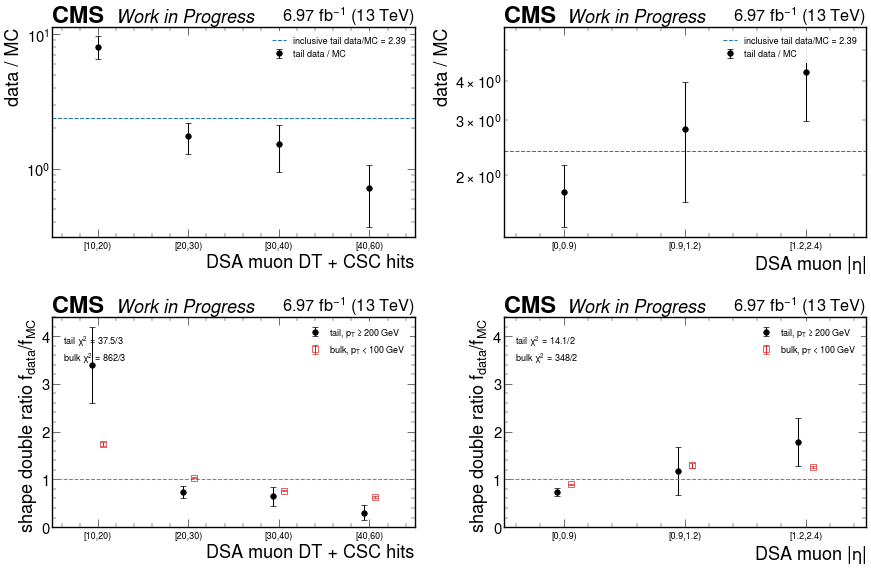

In [19]:
fig, axs = plt.subplots(2, 2, figsize=(18, 12))
for col, (name, groups, tag) in enumerate(SPLITS[::-1]):    # nHits left, |eta| right
    rows_t, tot_t = split_table(name, groups, CH_SPREAD, TAIL)
    drt, drb, c2t, c2b, ndf = DR[(tag, "Spread+cosAlpha")]
    x = np.arange(len(groups))
    labs = [g[0].replace(f"{tag} ", "") for g in groups]

    ax = axs[0, col]
    y, ey = zip(*[ratio_err(d, dvv, m, mvv) for _, d, dvv, m, mvv in rows_t])
    ax.errorbar(x, y, yerr=ey, fmt="o", color="k", markersize=8, capsize=4,
                label="tail data / MC")
    r0, _ = ratio_err(*tot_t)
    ax.axhline(r0, color="tab:blue", linestyle="--",
               label=f"inclusive tail data/MC = {r0:.2f}")
    ax.set_yscale("log")
    ax.set_ylabel("data / MC")
    ax.legend(fontsize=13, loc="upper right", frameon=True, facecolor="white",
              edgecolor="none", framealpha=0.92)

    ax = axs[1, col]
    ax.errorbar(x - 0.06, [r[3] for r in drt], yerr=[r[4] for r in drt], fmt="o",
                color="k", markersize=8, capsize=4, label=r"tail, $p_T \geq 200$ GeV")
    ax.errorbar(x + 0.06, [r[3] for r in drb], yerr=[r[4] for r in drb], fmt="s",
                markerfacecolor="none", color="tab:red", markersize=8, capsize=4,
                label=r"bulk, $p_T < 100$ GeV")
    ax.axhline(1.0, color="grey", linestyle="--")
    ax.set_ylabel(r"shape double ratio $f_{data}/f_{MC}$")
    ax.set_ylim(0, 4.4)
    ax.legend(fontsize=13, loc="upper right", frameon=True, facecolor="white",
              edgecolor="none", framealpha=0.92)
    ax.text(0.03, 0.92, f"tail $\\chi^2$ = {c2t:.1f}/{ndf}\nbulk $\\chi^2$ = {c2b:.0f}/{ndf}",
            transform=ax.transAxes, fontsize=13, va="top")

    for ax in (axs[0, col], axs[1, col]):
        ax.set_xticks(x)
        ax.set_xticklabels(labs, fontsize=13)
        ax.set_xlabel("DSA muon DT + CSC hits" if tag == "nHits" else r"DSA muon $|\eta|$")
        ax.set_xlim(-0.5, len(groups) - 0.5)
for ax in axs.ravel():
    hep.cms.label(data=True, lumi=LUMI_DATA, text="Work in Progress", ax=ax)
plt.tight_layout()
plt.show()
plt.close()

## 7. Where the cosmics went: the azimuthal handle

Cosmic muons arrive from above, so they populate `phi` near `+/- pi/2` and avoid `phi` near 0
and `+/- pi`. The handle used here is the ratio of the number of DSA muons within 0.5 rad of
`+/- pi/2` (**vertical**) to the number within 0.5 rad of 0 or `+/- pi` (**horizontal**). A
collision population gives a ratio near 1; the MC prediction for it is computed from the same
histogram and is not assumed.

The *observation* is data-driven: it uses no vertex information and no MC normalization, so it
is independent of everything in sections 3 and 6, and in particular of the normalization
mismatch of section 3.1. The *cosmic template* is not. It is measured in the **vertex-inverted
cosmic region** (`cosmic_muons_vtxChi2`), whose definition contains `no vtx or vtx_chi2 >= 5`,
so the template does use the vertex variable. The spread-inverted cosmic region of section 2b,
which uses none, was never run with the two-dimensional pT x phi histogram and so cannot supply
the template here. Everything below that depends on the template is stated as conditional on
it, and the cell after next measures how much it depends on it.

In [20]:
PH = "mu_lj_dsaMuon_pt_phi"
ph_edges = H_tail[PH][{"channel": CH_BEFORE}].axes[1].edges
ctr  = 0.5 * (ph_edges[1:] + ph_edges[:-1])
vert = np.array([min(abs(c - math.pi/2), abs(c + math.pi/2)) < 0.5 for c in ctr])
horz = np.array([min(abs(c), math.pi - abs(c)) < 0.5 for c in ctr])
print(f"phi bin centres      : {np.round(ctr, 3)}")
print(f"vertical bin indices : {np.where(vert)[0]}")
print(f"horizontal bin indices: {np.where(horz)[0]}")


def vh(v, e, rows):
    p, pe = prof(v, rows)[1:-1], prof(e, rows)[1:-1]
    return p[vert].sum(), math.sqrt(pe[vert].sum()), p[horz].sum(), math.sqrt(pe[horz].sum())


def vh_ratio(v, e, rows, poisson):
    V, Ve, H, He = vh(v, e, rows)
    if V <= 0 or H <= 0:
        return float("nan"), float("nan"), V, H
    r = V / H
    er = r * (math.sqrt(1/V + 1/H) if poisson else math.sqrt((Ve/V)**2 + (He/H)**2))
    return r, er, V, H


print(f"\n{'channel':22s} {'region':6s} {'V':>9s} {'H':>9s} {'V/H (data)':>18s} "
      f"{'V/H (MC)':>18s} {'double ratio':>18s}")
phi_res = {}
for lab, ch in TAIL_CHANS:
    for rows, rlab in ((TAIL, "tail"), (BULK200, "bulk")):
        rd, erd, V, H = vh_ratio(*dview(PH, ch), rows, True)
        if ch in (CH_BEFORE, CH_SPREAD):
            rm, erm, _, _ = vh_ratio(*mview(PH, ch), rows, False)
            dr  = rd / rm
            edr = dr * math.sqrt((erd/rd)**2 + (erm/rm)**2)
            mtxt, dtxt = f"{rm:8.3f} +/-{erm:5.3f}", f"{dr:8.3f} +/-{edr:5.3f}"
        else:
            rm = erm = float("nan")
            mtxt = dtxt = f"{'-':>18s}"
        phi_res[(lab, rlab)] = (rd, erd, rm, erm)
        print(f"{lab:22s} {rlab:6s} {V:9.0f} {H:9.0f} {rd:9.3f} +/-{erd:6.3f} "
              f"{mtxt:>18s} {dtxt:>18s}")

phi bin centres      : [-2.945 -2.553 -2.16  -1.767 -1.374 -0.982 -0.589 -0.196  0.196  0.589
  0.982  1.374  1.767  2.16   2.553  2.945]
vertical bin indices : [ 3  4 11 12]
horizontal bin indices: [ 0  7  8 15]

channel                region         V         H         V/H (data)           V/H (MC)       double ratio
Before                 tail        1186        97    12.227 +/- 1.291     1.295 +/-0.218     9.443 +/-1.875
Before                 bulk       21626     10985     1.969 +/- 0.023     0.971 +/-0.028     2.027 +/-0.062
Spread+cosAlpha        tail          77        82     0.939 +/- 0.149     1.234 +/-0.211     0.761 +/-0.177
Spread+cosAlpha        bulk       10593     10067     1.052 +/- 0.015     0.975 +/-0.028     1.079 +/-0.035
vertex-fit+cosAlpha    tail          47        43     1.093 +/- 0.231                  -                  -
vertex-fit+cosAlpha    bulk        7390      6951     1.063 +/- 0.018                  -                  -
vertex-inverted cosmic tail    

In [21]:
# 95% CL upper limit on a residual cosmic component in the post-veto tail, from the vertical
# fraction of the V+H sample: the cosmic template comes from the VERTEX-INVERTED cosmic region
# (cosmic_muons_vtxChi2), the non-cosmic template from MC in the same channel as the
# observation. The template therefore uses the vertex variable; the sensitivity scan below
# says how much that matters.
Vc, _, Hc, _ = vh(*dview(PH, CH_COSMIC), TAIL)
Vs, _, Hs, _ = vh(*dview(PH, CH_SPREAD), TAIL)
mv_ph, me_ph = mview(PH, CH_SPREAD)
Vm, Vme, Hm, Hme = vh(mv_ph, me_ph, TAIL)

f_cos = Vc / (Vc + Hc)
f_mc  = Vm / (Vm + Hm)
f_obs = Vs / (Vs + Hs)
n_obs = Vs + Hs
e_obs = math.sqrt(f_obs * (1 - f_obs) / n_obs)
e_mc  = f_mc * (1 - f_mc) * math.sqrt((Vme / Vm) ** 2 + (Hme / Hm) ** 2)

d_tail = prof(dview("mu_lj_dsaMuon_pt_nHits", CH_SPREAD)[0], TAIL).sum()
ul95   = f_obs + 1.645 * math.sqrt(e_obs ** 2 + e_mc ** 2)
f_ul   = max((ul95 - f_mc) / (f_cos - f_mc), 0.0)
print("vertical fraction among the V+H DSA muons of the tail:")
print(f"  vertex-inverted template : {f_cos:.4f}                (V={Vc:.0f}, H={Hc:.0f})")
print(f"  MC non-cosmic template   : {f_mc:.4f} +/- {e_mc:.4f}   (V={Vm:.2f}, H={Hm:.2f})")
print(f"  observed post-veto tail  : {f_obs:.4f} +/- {e_obs:.4f}   (V={Vs:.0f}, H={Hs:.0f})")
print(f"  best-fit cosmic fraction : {(f_obs - f_mc)/(f_cos - f_mc):+.4f}")
print(f"  95% CL upper limit       : {f_ul:.4f}  ->  fewer than {f_ul*d_tail:.1f} "
      f"of the {d_tail:.0f} tail events")

# How much does the limit depend on the template? Degrade the template's vertical fraction
# deliberately and redo the same one-sided limit.
print("\nSensitivity of the limit to the cosmic template's vertical fraction:")
for f_alt in (f_cos, 0.95, 0.90, 0.80):
    ul_alt = max((ul95 - f_mc) / (f_alt - f_mc), 0.0)
    tag = "   (as measured)" if f_alt == f_cos else ""
    print(f"  template vertical fraction {f_alt:.4f}  ->  cosmic fraction < {ul_alt:.4f} "
          f"at 95% CL{tag}")
print("  A template only 0.90 vertical - far more contaminated than the region's own V/H of")
print("  108 allows - moves the bound from 6.2% to 7.8%. The conclusion does not rest on the")
print("  template being pure, only on its being much more vertical than the observation.")

# The same two-template mixture applied to the PRE-veto tail: an estimate of its cosmic
# content that is independent of the veto-retention route used in section 6.
Vb, _, Hb, _ = vh(*dview(PH, CH_BEFORE), TAIL)
Vmb, _, Hmb, _ = vh(*mview(PH, CH_BEFORE), TAIL)
f_obs_b, f_mc_b = Vb / (Vb + Hb), Vmb / (Vmb + Hmb)
f_cos_before = (f_obs_b - f_mc_b) / (f_cos - f_mc_b)
print("\nThe same two-template mixture on the PRE-veto tail:")
print(f"  observed vertical fraction {f_obs_b:.4f} (V={Vb:.0f}, H={Hb:.0f}); MC non-cosmic "
      f"template {f_mc_b:.4f}")
print(f"  ->  cosmic fraction of the pre-veto tail = {f_cos_before:.3f}")
print("  Section 6 reached 0.87 for the same quantity from veto retention against the MC")
print("  prompt-muon reference, a completely different observable.")

print("\nWhere the muons of each channel sit in hit count (the same tail definition):")
yedges = H_tail["mu_lj_dsaMuon_pt_nHits"][{"channel": CH_BEFORE}].axes[1].edges
for lab, ch in TAIL_CHANS:
    dv = prof(dview("mu_lj_dsaMuon_pt_nHits", ch)[0], TAIL)
    lo, hi, tt = y_group(dv, yedges, 10, 20), y_group(dv, yedges, 20, 1e9), dv[1:-1].sum()
    print(f"  {lab:24s} n={tt:6.0f}   nHits [10,20) {lo:5.0f} ({100*lo/tt:5.1f}%)   "
          f">= 20 {hi:5.0f} ({100*hi/tt:5.1f}%)")

vertical fraction among the V+H DSA muons of the tail:
  vertex-inverted template : 0.9908                (V=753, H=7)
  MC non-cosmic template   : 0.5525 +/- 0.0422   (V=24.68, H=19.99)
  observed post-veto tail  : 0.4843 +/- 0.0396   (V=77, H=82)
  best-fit cosmic fraction : -0.1556
  95% CL upper limit       : 0.0617  ->  fewer than 19.1 of the 309 tail events

Sensitivity of the limit to the cosmic template's vertical fraction:
  template vertical fraction 0.9908  ->  cosmic fraction < 0.0617 at 95% CL   (as measured)
  template vertical fraction 0.9500  ->  cosmic fraction < 0.0680 at 95% CL
  template vertical fraction 0.9000  ->  cosmic fraction < 0.0778 at 95% CL
  template vertical fraction 0.8000  ->  cosmic fraction < 0.1093 at 95% CL
  A template only 0.90 vertical - far more contaminated than the region's own V/H of
  108 allows - moves the bound from 6.2% to 7.8%. The conclusion does not rest on the
  template being pure, only on its being much more vertical than the obse

**How to read Figure 11:** the DSA-muon `phi` distribution above 200 GeV, each channel
normalized to unit area so only the shape is compared; the dotted vertical lines mark
`+/- pi/2`, where a cosmic population peaks, and the shaded bands mark the horizontal windows
it avoids. The grey dashed curve is the vertex-inverted cosmic region, used as the template.

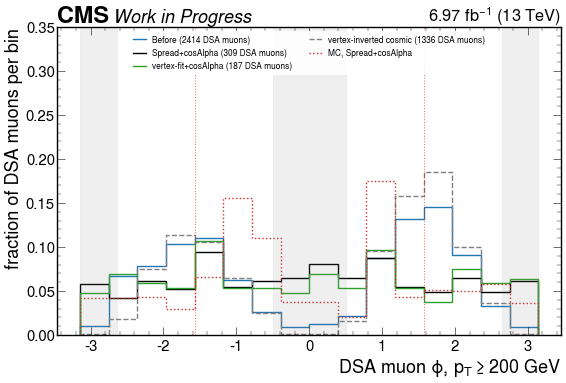

In [22]:
fig, ax = plt.subplots(figsize=(13, 8))
styles = {"Before": dict(color="tab:blue"), "Spread+cosAlpha": dict(color="k"),
          "vertex-fit+cosAlpha": dict(color="tab:green"),
          "vertex-inverted cosmic": dict(color="grey", linestyle="--")}
for lab, ch in TAIL_CHANS:
    p = prof(dview(PH, ch)[0], TAIL)[1:-1]
    hep.histplot(p / p.sum(), ph_edges, ax=ax, histtype="step", linewidth=2,
                 label=f"{lab} ({p.sum():.0f} DSA muons)", **styles[lab])
mp = prof(mview(PH, CH_SPREAD)[0], TAIL)[1:-1]
hep.histplot(mp / mp.sum(), ph_edges, ax=ax, histtype="step", linewidth=2,
             color="tab:red", linestyle=":", label="MC, Spread+cosAlpha")
for x in (-math.pi/2, math.pi/2):
    ax.axvline(x, color="red", linestyle=":", alpha=0.6)
for lo, hi in ((-math.pi, -math.pi + 0.5), (-0.5, 0.5), (math.pi - 0.5, math.pi)):
    ax.axvspan(lo, hi, color="grey", alpha=0.12)
ax.set_xlabel(r"DSA muon $\phi$, $p_{T} \geq 200$ GeV")
ax.set_ylabel("fraction of DSA muons per bin")
ax.set_ylim(0, 0.35)
ax.legend(fontsize=12, ncol=2, loc="upper center", frameon=True, facecolor="white",
          edgecolor="none", framealpha=0.92)
hep.cms.label(data=True, lumi=LUMI_DATA, text="Work in Progress", ax=ax)
plt.show()
plt.close()

The azimuthal handle settles the question the study was opened for.

**Before the veto the tail is cosmic beyond argument.** Its vertical-to-horizontal ratio is
12.2 +/- 1.3, against 1.29 +/- 0.22 in MC - a data/MC double ratio of 9.4 +/- 1.9 - and the
vertex-inverted cosmic template sits at 107.6 +/- 40.8. Fitting the pre-veto vertical fraction
to the same two-template mixture puts the cosmic content of the pre-veto tail at 0.84,
in agreement with the independent veto-retention estimate of ~87% in section 6. The bulk of the same channel is at 1.97,
which is itself elevated because cosmics leak into it, and the MC bulk is 0.97.

**After the veto it is not cosmic.** The post-Spread-veto tail ratio is 0.94 +/- 0.15 and the
post-vertex-veto tail ratio is 1.09 +/- 0.23, both consistent with the MC expectation of
1.23 +/- 0.21 and both incompatible with the cosmic template by a wide margin. Fitting the
observed vertical fraction to a two-template mixture bounds the residual cosmic component at

    < 6% of the surviving tail at 95% CL, i.e. fewer than 19 of the 309 events.

The best fit is negative, so this is a genuine upper limit and not a measurement.

**The cosmic sample available here is high-hit-count, and that is weaker than it sounds.** The
vertex-inverted cosmic region's tail is 93.9% `nHits >= 20`, against 89.6% in the pre-veto tail
and 59.2% in the post-veto tail. The tempting reading - "the low-nHits survivors of section 6
are therefore not cosmic" - is not supported, because the template is biased against exactly
the tracks in question: the region requires a back-to-back muon *pair*, and cosAlpha near -1 is
the quantity a short, poorly measured track reconstructs worst, so low-nHits cosmics are
under-selected by the region's own definition. What survives that objection is only the weaker
statement: **the vertex-inverted cosmic region, the only cosmic-enriched sample available here,
contains few low-nHits tracks, so it offers no evidence that the survivors are cosmic - and
none that they are not.**

**Caveat on the limit.** No `phi` x `nHits` histogram was booked, so the cosmic limit is
inclusive over the tail: it constrains the tail as a whole and not each part of it. If a cosmic
residual were confined entirely to the 126-event low-nHits subset it could reach roughly 15% of
that subset while still respecting the inclusive 6% bound. Together with the template bias
above, that is why the low-nHits question is genuinely open. The `phi` x `nHits` histogram is
the prerequisite for closing it, and it is the first item of section 9.4.

## 8. An independent control sample: DSA against PF momentum

Sections 6 and 7 say what the surviving tail is not. This section asks what could produce it,
using a control sample that shares no selection with the lepton-jet tail.

**Method.** In the same events, the raw `DSAMuon` collection is re-selected with the same
identification cuts the lepton-jet DSA muons pass, **minus the cross-cleaning against PF
muons**, and each surviving DSA muon is matched to a selected PF muon within `dR < 0.2`. The
observable is the response

    r = pT(DSA) / pT(PF),

the PF measurement standing in for the truth. Because the LJ DSA muons are by construction the
ones *without* a PF partner, the matched sample is disjoint from the tail it is used to
describe, and no veto has been applied to it.

**What the method is not.** The re-selection drops the cross-cleaning, which in the analysis
channels is a segment-based match rather than a `dR` match, so this control sample is close to
but not the exact complement of the LJ DSA population. It is a sizing tool, not a
substitution.

Two numbers are extracted: the fraction of matched muons in the response tail, and the
probability that a low-pT PF muon is reconstructed as a high-pT DSA muon.

In [23]:
RH_N, RH_E = "dsaPfMatch_response_nHits", "dsaPfMatch_response_abseta"
r_edges = H_tail[RH_N][{"channel": CH_BEFORE}].axes[0].edges
LOGR    = np.log10(r_edges)


def frac_above_interp(v1d, thr):
    """Entries with r > thr from a flow-included 1D response array.

    The response axis is uniform in log10(r), so the bin straddling the threshold is split
    log-linearly instead of being snapped to the nearest edge (which would move an
    r > 2 cut to r > 1.88 or r > 2.24 and shift the answer by several per cent).
    """
    lt = math.log10(thr)
    j = int(np.searchsorted(LOGR, lt, side="right")) - 1
    n = float(v1d[j + 2:].sum())
    n += float(v1d[j + 1]) * (LOGR[j + 1] - lt) / (LOGR[j + 1] - LOGR[j])
    return n, float(v1d.sum())


def p_above(dv, mv, mvar, thr):
    dn, dt = frac_above_interp(dv, thr)
    mn, mt = frac_above_interp(mv, thr)
    mnv, mtv = frac_above_interp(mvar, thr)
    p_d, p_m = dn / dt, mn / mt
    e_d = math.sqrt(dn) / dt
    e_m = math.sqrt(max(mnv * (1 - p_m) ** 2 + (mtv - mnv) * p_m ** 2, 0.0)) / mt
    rr = p_d / p_m
    return p_d, e_d, p_m, e_m, rr, rr * math.sqrt((e_d/p_d) ** 2 + (e_m/p_m) ** 2), dn


dv_r, _   = dview(RH_N, CH_BEFORE)
mv_r, me_r = mview(RH_N, CH_BEFORE)
d1, m1, v1 = dv_r.sum(axis=1), mv_r.sum(axis=1), me_r.sum(axis=1)
print(f"matched DSA-PF muons in the Before channel: data {d1.sum():.0f}, "
      f"MC {m1.sum():.1f} +/- {math.sqrt(v1.sum()):.1f}  ->  data/MC {d1.sum()/m1.sum():.3f}")
print(f"response-axis flow: data r<0.1 {d1[0]:.0f}, r>100 {d1[-1]:.0f}\n")

RESP = {}
for thr in (2.0, 5.0):
    p_d, e_d, p_m, e_m, rr, er, dn = p_above(d1, m1, v1, thr)
    RESP[thr] = (rr, er)
    print(f"P(r > {thr:g}) : data {p_d:.5f} +/- {e_d:.5f} (N = {dn:.0f})   "
          f"MC {p_m:.5f} +/- {e_m:.5f}   ->  data/MC {rr:.3f} +/- {er:.3f}")

print("\nIs the mismodelling flat? Same interpolated P(r > 2), sliced in nHits and |eta|:")
FLAT = {}
for hn, axn, lab, groups in (
        (RH_N, "dsaPfMatch_nHits", "nHits",
         [(3, 4, "[10,15)"), (4, 5, "[15,20)"), (5, 6, "[20,25)"), (6, 7, "[25,30)"),
          (7, 8, "[30,35)"), (8, 9, "[35,40)"), (9, 14, "[40,inf)")]),
        (RH_E, "dsaPfMatch_abseta", "|eta|",
         [(1, 7, "0.0-0.6"), (7, 13, "0.6-1.2"), (13, 19, "1.2-1.8"),
          (19, 22, "1.8-2.1"), (22, 25, "2.1-2.4")])):
    dv_, _ = dview(hn, CH_BEFORE)
    mv_, me_ = mview(hn, CH_BEFORE)
    rs, ers, labs = [], [], []
    for a, b, gl in groups:
        _, _, _, _, rr, er, dn = p_above(dv_[:, a:b].sum(axis=1), mv_[:, a:b].sum(axis=1),
                                         me_[:, a:b].sum(axis=1), 2.0)
        if dn < 20:
            continue
        rs.append(rr); ers.append(er); labs.append(gl)
    rs, ers = np.array(rs), np.array(ers)
    w  = 1 / ers ** 2
    c  = (rs * w).sum() / w.sum()
    x2 = float((((rs - c) / ers) ** 2).sum())
    FLAT[lab] = (c, x2, len(rs) - 1, rs.min(), rs.max())
    print(f"  {lab:6s}: " + "  ".join(f"{l}={a:.2f}+/-{b:.2f}"
                                      for l, a, b in zip(labs, rs, ers)))
    print(f"          best flat value {c:.3f}, chi2 = {x2:.2f}/{len(rs)-1}, "
          f"range {rs.min():.2f} - {rs.max():.2f}")

matched DSA-PF muons in the Before channel: data 402820, MC 442643.6 +/- 1732.8  ->  data/MC 0.910
response-axis flow: data r<0.1 73, r>100 2

P(r > 2) : data 0.06678 +/- 0.00041 (N = 26902)   MC 0.03697 +/- 0.00071   ->  data/MC 1.806 +/- 0.037
P(r > 5) : data 0.00928 +/- 0.00015 (N = 3737)   MC 0.00436 +/- 0.00025   ->  data/MC 2.126 +/- 0.127

Is the mismodelling flat? Same interpolated P(r > 2), sliced in nHits and |eta|:
  nHits : [10,15)=1.19+/-0.28  [15,20)=1.81+/-0.08  [20,25)=1.50+/-0.05  [25,30)=2.01+/-0.12  [30,35)=1.96+/-0.10  [35,40)=1.45+/-0.12  [40,inf)=1.35+/-0.10
          best flat value 1.619, chi2 = 45.50/6, range 1.19 - 2.01
  |eta| : 0.0-0.6=1.85+/-0.06  0.6-1.2=1.62+/-0.06  1.2-1.8=2.18+/-0.10  1.8-2.1=1.72+/-0.13  2.1-2.4=1.07+/-0.10
          best flat value 1.714, chi2 = 69.83/4, range 1.07 - 2.18


**How to read Figure 12:** the matched DSA-to-PF momentum response, data against the eight-sample
MC, each normalized to unit area, on logarithmic axes so the tail out to `r = 100` is visible;
the dotted lines mark `r = 2` and `r = 5`. The core agrees; the data tail does not.

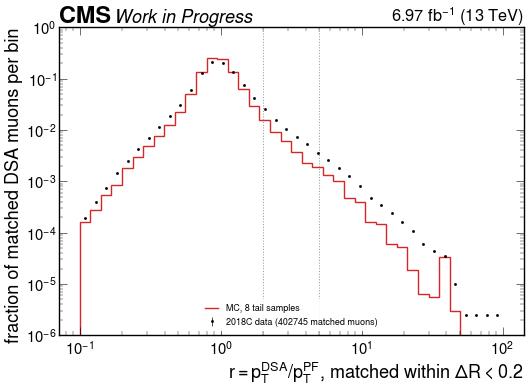

In [24]:
fig, ax = plt.subplots(figsize=(12, 8))
d_r = d1[1:-1]
m_r = m1[1:-1]
hep.histplot(d_r / d_r.sum(), r_edges, ax=ax, histtype="errorbar", color="k",
             label=f"2018C data ({d_r.sum():.0f} matched muons)")
hep.histplot(m_r / m_r.sum(), r_edges, ax=ax, histtype="step", linewidth=2, color="tab:red",
             label="MC, 8 tail samples")
for t in (2, 5):
    ax.axvline(t, color="grey", linestyle=":", alpha=0.8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1e-6, 1)
ax.set_xlabel(r"$r = p_{T}^{DSA} / p_{T}^{PF}$, matched within $\Delta R < 0.2$")
ax.set_ylabel("fraction of matched DSA muons per bin")
ax.legend(fontsize=13, loc="lower center", frameon=True, facecolor="white",
          edgecolor="none", framealpha=0.92)
hep.cms.label(data=True, lumi=LUMI_DATA, text="Work in Progress", ax=ax)
plt.show()
plt.close()

In [25]:
FH = "dsaPfMatch_ptPf_ptDsa"
pf_e = H_tail[FH][{"channel": CH_BEFORE}].axes[0].edges
ds_e = H_tail[FH][{"channel": CH_BEFORE}].axes[1].edges
dv_f, _   = dview(FH, CH_BEFORE)
mv_f, me_f = mview(FH, CH_BEFORE)


def feedup(pf_max=100.0, dsa_min=200.0):
    """P(pT_DSA >= dsa_min | pT_PF < pf_max) in data and MC, and the ratio."""
    i_pf = int(np.searchsorted(pf_e, pf_max, side="left"))
    i_ds = int(np.searchsorted(ds_e, dsa_min, side="left"))
    dd, mm, mv_ = dv_f[0:i_pf+1, :], mv_f[0:i_pf+1, :], me_f[0:i_pf+1, :]
    dnum, dden = dd[:, i_ds+1:].sum(), dd.sum()
    mnum, mden = mm[:, i_ds+1:].sum(), mm.sum()
    mnum_e, mden_e = math.sqrt(mv_[:, i_ds+1:].sum()), math.sqrt(mv_.sum())
    p_d, p_m = dnum / dden, mnum / mden
    e_d = math.sqrt(dnum) / dden
    e_m = p_m * math.sqrt((mnum_e/mnum) ** 2 + (mden_e/mden) ** 2)
    rr = p_d / p_m
    return dict(dnum=dnum, dden=dden, p_d=p_d, e_d=e_d, p_m=p_m, e_m=e_m,
                ratio=rr, e_ratio=rr * math.sqrt((e_d/p_d)**2 + (e_m/p_m)**2))


FU = feedup()
print("Feed-up probability P(pT_DSA >= 200 GeV | pT_PF < 100 GeV), Before channel:")
print(f"  data {FU['dnum']:.0f} / {FU['dden']:.0f} = {FU['p_d']:.6f} +/- {FU['e_d']:.6f}")
print(f"  MC                       = {FU['p_m']:.6f} +/- {FU['e_m']:.6f}")
print(f"  data/MC                  = {FU['ratio']:.3f} +/- {FU['e_ratio']:.3f}")

print("\nSame probability bin by bin in pT_PF:")
i_ds = int(np.searchsorted(ds_e, 200.0, side="left"))
fu_x, fu_r, fu_er = [], [], []
print(f"  {'pT_PF bin':>14s} {'data N':>8s} {'P(data)':>11s} {'P(MC)':>11s} {'data/MC':>9s}")
for j in range(1, len(pf_e)):
    dnum, dden = dv_f[j, i_ds+1:].sum(), dv_f[j, :].sum()
    mnum, mden = mv_f[j, i_ds+1:].sum(), mv_f[j, :].sum()
    if dden < 100 or mnum <= 0:
        continue
    p_d, p_m = dnum / dden, mnum / mden
    e_d = math.sqrt(dnum) / dden
    e_m = p_m * math.sqrt(me_f[j, i_ds+1:].sum() / mnum ** 2 + me_f[j, :].sum() / mden ** 2)
    rr = p_d / p_m
    fu_x.append(0.5 * (pf_e[j-1] + pf_e[j]))
    fu_r.append(rr)
    fu_er.append(rr * math.sqrt((e_d/p_d) ** 2 + (e_m/p_m) ** 2))
    print(f"  [{pf_e[j-1]:5.0f},{pf_e[j]:5.0f}) {dnum:8.0f} {p_d:11.3e} {p_m:11.3e} {rr:9.2f}")

Feed-up probability P(pT_DSA >= 200 GeV | pT_PF < 100 GeV), Before channel:
  data 3137 / 394257 = 0.007957 +/- 0.000142
  MC                       = 0.002291 +/- 0.000161
  data/MC                  = 3.474 +/- 0.252

Same probability bin by bin in pT_PF:
       pT_PF bin   data N     P(data)       P(MC)   data/MC
  [    0,   10)       25   8.015e-03   1.643e-03      4.88
  [   10,   20)       37   2.769e-03   1.902e-03      1.46
  [   20,   30)      270   2.961e-03   1.115e-03      2.66
  [   30,   40)      603   4.378e-03   1.535e-03      2.85
  [   40,   50)      558   7.232e-03   2.170e-03      3.33
  [   50,   60)      424   1.249e-02   2.487e-03      5.02
  [   60,   80)      694   2.500e-02   5.362e-03      4.66
  [   80,  100)      526   5.275e-02   1.675e-02      3.15
  [  100,  150)      694   1.063e-01   4.682e-02      2.27
  [  150,  200)      264   2.039e-01   1.946e-01      1.05
  [  200,  300)      170   3.114e-01   4.141e-01      0.75
  [  300,  500)       69   3.920e-0

**How to read Figure 13:** left panel, the probability that a matched muon reconstructed by PF
below the abscissa is reconstructed by DSA above 200 GeV, data against MC, against the PF pT
bin; right panel, the data/MC ratio of that probability, with the dashed line at the value
integrated over `pT_PF < 100` GeV. The rise of both curves toward high `pT_PF` is kinematic -
a 150 GeV PF muon needs much less mismeasurement to land above 200 GeV than a 30 GeV one; the
statement is the *ratio*, and the shaded band marks the window the control number is taken in.
Error bars are statistical: Poisson on the data numerator, weighted-MC on the simulation.

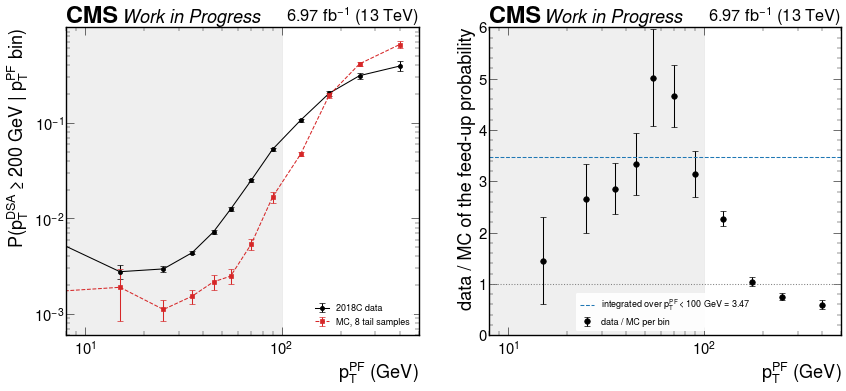

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(20, 8))
centres = 0.5 * (pf_e[1:] + pf_e[:-1])
p_data, e_data, p_mc, e_mc_ = [], [], [], []
for j in range(1, len(pf_e)):
    dnum, dden = dv_f[j, i_ds+1:].sum(), dv_f[j, :].sum()
    mnum, mden = mv_f[j, i_ds+1:].sum(), mv_f[j, :].sum()
    p_data.append(dnum / dden if dden else np.nan)
    e_data.append(math.sqrt(dnum) / dden if dden else np.nan)
    p_mc.append(mnum / mden if mden else np.nan)
    e_mc_.append((mnum / mden) * math.sqrt(me_f[j, i_ds+1:].sum() / mnum ** 2
                                           + me_f[j, :].sum() / mden ** 2)
                 if (mden and mnum > 0) else np.nan)
axs[0].errorbar(centres, p_data, yerr=e_data, fmt="o-", color="k", capsize=4,
                label="2018C data")
axs[0].errorbar(centres, p_mc, yerr=e_mc_, fmt="s--", color="tab:red", capsize=4,
                label="MC, 8 tail samples")
axs[0].set_yscale("log")
axs[0].set_ylabel(r"P($p_T^{DSA} \geq 200$ GeV | $p_T^{PF}$ bin)")
axs[1].errorbar(fu_x, fu_r, yerr=fu_er, fmt="o", color="k", capsize=4, markersize=8,
                label="data / MC per bin")
axs[1].axhline(FU["ratio"], color="tab:blue", linestyle="--",
               label=f"integrated over $p_T^{{PF}} < 100$ GeV = {FU['ratio']:.2f}")
axs[1].axhline(1.0, color="grey", linestyle=":")
axs[1].set_ylabel("data / MC of the feed-up probability")
axs[1].set_ylim(0, 6)
for ax in axs:
    ax.axvspan(0, 100, color="grey", alpha=0.12)
    ax.set_xscale("log")
    ax.set_xlim(8, 500)
    ax.set_xlabel(r"$p_T^{PF}$ (GeV)")
    ax.legend(fontsize=13, frameon=True, facecolor="white", edgecolor="none",
              framealpha=0.92)
    hep.cms.label(data=True, lumi=LUMI_DATA, text="Work in Progress", ax=ax)
plt.show()
plt.close()

In [27]:
# Does the measured feed-up rate account for the LJ DSA tail? The test is a ratio of two
# RATES, each measured entirely within one sample, so the control region's normalization
# mismatch (section 3.1) and the eight-sample set's missing bulk (section 5) cancel out of it.
NH = "mu_lj_dsaMuon_pt_nHits"
lj = {}
for ch, clab in ((CH_BEFORE, "Before"), (CH_SPREAD, "Spread+cosAlpha")):
    dv_ = dview(NH, ch)[0]
    mv_, mvar_ = mview(NH, ch)
    lj[clab] = dict(d_tot=dv_.sum(), d_tail=prof(dv_, TAIL).sum(),
                    m_tot=mv_.sum(), m_tail=prof(mv_, TAIL).sum(),
                    m_tail_e=math.sqrt(prof(mvar_, TAIL).sum()))

print("LJ DSA-muon tail rate against the matched feed-up rate measured above.")
print("The two populations have different true-pT spectra, so this is a scale test, not a")
print("proof - but data and MC are held to exactly the same test.\n")
print(f"  {'':22s} {'N(tail)':>9s} {'N(all)':>10s} {'tail rate':>11s} "
      f"{'feed-up rate':>13s} {'ratio':>16s}")
CLOS = {}
for clab in ("Before", "Spread+cosAlpha"):
    for who, tail, tail_e, tot_, rate, rate_e in (
            ("data", lj[clab]["d_tail"], math.sqrt(lj[clab]["d_tail"]),
             lj[clab]["d_tot"], FU["p_d"], FU["e_d"]),
            ("MC  ", lj[clab]["m_tail"], lj[clab]["m_tail_e"],
             lj[clab]["m_tot"], FU["p_m"], FU["e_m"])):
        rr = tail / tot_ / rate
        err = rr * math.sqrt((tail_e / tail) ** 2 + (rate_e / rate) ** 2)
        CLOS[(clab, who.strip())] = (rr, err)
        print(f"  {clab:16s} {who}  {tail:9.1f} {tot_:10.1f} {tail/tot_:11.3e} "
              f"{rate:13.3e} {rr:9.3f} +/-{err:5.3f}")

print("\nThe four closure numbers, and what each one says:")
print(f"  data, post-veto : {CLOS[('Spread+cosAlpha','data')][0]:.3f} "
      f"+/- {CLOS[('Spread+cosAlpha','data')][1]:.3f}  the surviving tail is the size the "
      f"data's OWN feed-up rate predicts")
print(f"  MC,   post-veto : {CLOS[('Spread+cosAlpha','MC')][0]:.3f} "
      f"+/- {CLOS[('Spread+cosAlpha','MC')][1]:.3f}  the same test inside simulation")
print(f"  MC,   pre-veto  : {CLOS[('Before','MC')][0]:.3f} "
      f"+/- {CLOS[('Before','MC')][1]:.3f}  MC self-closure; MC has no cosmics to remove")
print(f"  data, pre-veto  : {CLOS[('Before','data')][0]:.3f} "
      f"+/- {CLOS[('Before','data')][1]:.3f}  misses by the cosmic population")
print("  The MC numbers stand on a tail of ~35 effective MC events, hence the ~18% errors:")
print("  they are consistent with the MC tail being pure feed-up and equally consistent with")
print("  a second component of up to about a third of it.")

print("\nWhy the 'predicted vs measured tail data/MC' form of this statement is NOT used:")
pred = (lj["Spread+cosAlpha"]["d_tot"] / lj["Spread+cosAlpha"]["m_tot"]) * FU["ratio"]
meas, e_meas = ratio_err(lj["Spread+cosAlpha"]["d_tail"], lj["Spread+cosAlpha"]["d_tail"],
                         lj["Spread+cosAlpha"]["m_tail"], lj["Spread+cosAlpha"]["m_tail_e"] ** 2)
print(f"  pred = (N_data/N_MC) x feed-up ratio = "
      f"{lj['Spread+cosAlpha']['d_tot']/lj['Spread+cosAlpha']['m_tot']:.3f} x "
      f"{FU['ratio']:.3f} = {pred:.3f}, against a measured {meas:.3f} +/- {e_meas:.3f}.")
print(f"  pred / meas = {pred/meas:.4f}, which is ALGEBRAICALLY IDENTICAL to")
print(f"  (MC closure) / (data closure) = "
      f"{CLOS[('Spread+cosAlpha','MC')][0]/CLOS[('Spread+cosAlpha','data')][0]:.4f}.")
print("  The two forms carry exactly the same information, so 'the prediction agrees with the")
print("  measurement' is not a second, independent check. Worse, N_MC there is the")
print("  eight-sample set's TOTAL yield, which section 5 showed covers 52.8% of the full")
print("  stack, so 0.716 is not a normalization ratio at all.")
_fs_tot  = sum(tot(s, CH_SPREAD, scale=ratio) for s in summed_MC)
_fs_tail = sum(tot(s, CH_SPREAD, 200, scale=ratio) for s in summed_MC)
_d_tot, _d_tail = lj["Spread+cosAlpha"]["d_tot"], lj["Spread+cosAlpha"]["d_tail"]
print(f"  Substituting the full stack: N_data/N_MC = {_d_tot:.0f}/{_fs_tot:.1f} = "
      f"{_d_tot/_fs_tot:.3f}, times {FU['ratio']:.3f} = {_d_tot/_fs_tot*FU['ratio']:.2f},")
print(f"  against a full-stack measured {_d_tail:.0f}/{_fs_tail:.1f} = "
      f"{_d_tail/_fs_tail:.2f}. That substitution is INDICATIVE ONLY: dsa_pf_response was")
print("  never run on the full stack, so the feed-up ratio 3.47 is the eight-sample")
print("  measurement and does not belong beside a full-stack normalization.")

print("\nHow much of the closure is a choice of window? Moving the pT_PF threshold:")
print(f"  {'window':>18s} {'feed-up ratio':>16s} {'data closure':>14s} {'MC closure':>12s}")
for pf_max in (60.0, 100.0, 150.0, 500.0):
    f = feedup(pf_max=pf_max)
    c_d = (lj["Spread+cosAlpha"]["d_tail"] / lj["Spread+cosAlpha"]["d_tot"]) / f["p_d"]
    c_m = (lj["Spread+cosAlpha"]["m_tail"] / lj["Spread+cosAlpha"]["m_tot"]) / f["p_m"]
    print(f"  {'pT_PF < ' + format(pf_max, '.0f'):>18s} "
          f"{f['ratio']:8.3f} +/-{f['e_ratio']:5.3f} {c_d:14.3f} {c_m:12.3f}")

LJ DSA-muon tail rate against the matched feed-up rate measured above.
The two populations have different true-pT spectra, so this is a scale test, not a
proof - but data and MC are held to exactly the same test.

                           N(tail)     N(all)   tail rate  feed-up rate            ratio
  Before           data     2414.0    63040.0   3.829e-02     7.957e-03     4.813 +/-0.130
  Before           MC        133.7    59982.6   2.228e-03     2.291e-03     0.973 +/-0.174
  Spread+cosAlpha  data      309.0    40881.0   7.559e-03     7.957e-03     0.950 +/-0.057
  Spread+cosAlpha  MC        129.5    57091.1   2.269e-03     2.291e-03     0.991 +/-0.181

The four closure numbers, and what each one says:
  data, post-veto : 0.950 +/- 0.057  the surviving tail is the size the data's OWN feed-up rate predicts
  MC,   post-veto : 0.991 +/- 0.181  the same test inside simulation
  MC,   pre-veto  : 0.973 +/- 0.174  MC self-closure; MC has no cosmics to remove
  data, pre-veto  : 4.813 

The control sample says three things.

**The response tail is mismodelled, by a factor between 1.8 and 2.1.** Data over-produces
`r > 2` by 1.806 +/- 0.037 and `r > 5` by 2.126 +/- 0.127 relative to MC. Both use a
log-linear interpolation inside the bin that straddles the threshold, because the response
axis has only four bins per decade and snapping `r > 2` to the nearest edge moves it to 1.88
or 2.24 and changes the answer by several per cent.

**The mismodelling is not flat, so no single number transports it.** Sliced in `|eta|` the
`P(r > 2)` ratio varies from 1.07 to 2.18 with a chi2 of 69.8/4 against a constant, the
maximum sitting in `1.2 <= |eta| < 1.8` (in the native 0.1-wide binning the bins near
`|eta| = 1.6-1.8` reach 3.2); sliced in nHits it varies from
1.19 to 2.01 with a chi2 of 45.5/6. A correction derived here and applied to a differently
distributed population carries that spread as a systematic.

**The surviving tail is the size its own feed-up rate predicts.** The relevant number is the
feed-up probability: a matched muon with `pT_PF < 100` GeV is reconstructed as a
`pT_DSA >= 200` GeV muon 3.474 +/- 0.252 times more often in data than in MC. The statement is
made as a ratio of two *rates*, each measured within a single sample, so it uses no MC
normalization and is untouched by the control region's normalization mismatch (section 3.1) and
by the eight-sample set's missing bulk (section 5):

    data: (post-veto tail rate) / (data feed-up rate) = 0.95 +/- 0.06
    MC:   (post-veto tail rate) / (MC   feed-up rate) = 0.99 +/- 0.18

Both are consistent with one. The same test before the veto misses by 4.81 +/- 0.13 in data -
the cosmic population, which is exactly what section 7 identified and what the veto removes -
while MC, which has no cosmics to remove, closes at 0.97 +/- 0.17 before the veto and
0.99 +/- 0.18 after it.

Three things that statement does **not** say.

1. **It is not a per-cent-level MC self-closure.** The MC number is 0.97 +/- 0.17: an
   18%-precision test standing on a tail of 35 effective MC events, and the same test swings
   between 0.57 and 1.35 as the `pT_PF` window moves. It is consistent with the MC high-pT DSA
   tail being resolution feed-up, and equally consistent with a second component contributing
   up to about a third of it. "In simulation the tail *is* feed-up and nothing else" is not
   something a measurement of this precision can establish.
2. **It is not a prediction that was then confirmed.** The tempting alternative form folds the
   feed-up ratio into the eight-sample set's total-yield ratio to "predict" a post-veto tail
   data/MC of 2.49, and compares that with the measured 2.39. The comparison is empty: the
   two sides differ *exactly* by the ratio of the two closure numbers above, so their agreement
   is the same statement written twice, not a second check. It also rests on the eight-sample
   set's total MC yield, which covers 52.8% of the full stack, so its 0.716 is not a
   normalization. Substituting the full stack gives 0.378 x 3.474 = 1.31 against a full-stack
   measured 2.31 - and even that is indicative only, since `dsa_pf_response` was never run on
   the full stack and the 3.474 is the eight-sample measurement.
3. **It is not window-independent.** The data closure moves between 0.70 and 1.41 and the MC
   closure between 0.57 and 1.35 as the `pT_PF` window moves from 500 down to 60 GeV, and the
   two move together. The control rate is measured before any veto, on a matched population
   whose true-pT spectrum differs from the lepton jets', and the mismodelling is not flat in
   `|eta|` or nHits.

What can be said, then: the surviving excess is of the size DSA momentum mismeasurement would
produce, at roughly factor-1.5 precision, and no additional source is required to accommodate
it. The raw tail data/MC of 2.4 +/- 0.4 is the weaker of the two statements, because its
denominator carries the section-3.1 normalization mismatch; the rate closure does not.

## 9. Candidate handles

Three ways of acting on the tail were examined. **None of them makes data and MC agree**, and
each is quoted with what it costs, so that the trade can be made explicitly rather than by
picking the cut that looks best on one number.

The signal cost of the hit-count cut needs `mu_lj_dsaMuon_pt_nHits` on signal, which the
180-sample production predates. It comes from `vtxChi2_signal_2018_nhits`, a 26-sample subset
of the same grid re-run after that histogram was added: 13 4Mu and 13 2Mu2E points, five
mediator masses, two dark-photon masses and eleven lifetimes.

In [28]:
NHSIG_DIR = f"{sidm_path}/RunOutputFiles/vtxChi2_signal_2018_nhits"
nh_files  = sorted(glob.glob(f"{NHSIG_DIR}/*.coffea"))
nh_names  = [os.path.basename(f)[:-len(".coffea")] for f in nh_files]

nh_rows = []
flow_audit = dict(total=0.0, pt_uf=0.0, pt_of=0.0, nh_uf=0.0, nh_of=0.0)
for f, n in zip(nh_files, nh_names):
    H = coffea.util.load(f)["out"][n]["hists"]["mu_lj_dsaMuon_pt_nHits"]
    hh = H[{"channel": SIG_REF}]
    v, var = hh.values(flow=True), hh.variances(flow=True)
    pe, ye = hh.axes[0].edges, hh.axes[1].edges
    tail = pt_rows(pe, "tail")
    bulk = pt_rows(pe, "bulk200")
    keep = np.concatenate(([False], ye[:-1] >= 20, [True]))   # nHits >= 20, overflow kept
    sp = H[{"channel": SIG_SPREAD}].values(flow=True)
    fs, m, ma, ct = parse_sample(n)
    flow_audit["total"] += v.sum()
    flow_audit["pt_uf"] += v[0, :].sum();  flow_audit["pt_of"] += v[-1, :].sum()
    flow_audit["nh_uf"] += v[:, 0].sum();  flow_audit["nh_of"] += v[:, -1].sum()
    nh_rows.append(dict(
        name=n, m=m, ma=ma, ct=ct, w=float(v.sum()),
        neff=float(v.sum() ** 2 / var.sum()),
        neff_tail=float(v[tail].sum() ** 2 / var[tail].sum()) if var[tail].sum() else 0.0,
        keep_all=float(v[:, keep].sum() / v.sum()),
        keep_bulk=float(v[bulk][:, keep].sum() / v[bulk].sum()),
        keep_tail=float(v[tail][:, keep].sum() / v[tail].sum()) if v[tail].sum() else np.nan,
        w_tail=float(v[tail].sum()),
        eff_spread=float(sp.sum() / v.sum()),
        keep_after_spread=float(sp[:, keep].sum() / sp.sum()),
    ))

NHW = np.array([r["w"] for r in nh_rows])
wavg = lambda k, w=NHW: float(np.nansum([r[k] for r in nh_rows] * w) / w.sum())
print(f"{len(nh_names)} signal samples in {os.path.basename(NHSIG_DIR)}")
print(f"flow audit over the subset: {flow_audit['total']:.3f} weighted DSA-muon entries; "
      f"pT underflow {flow_audit['pt_uf']:.3f}, pT overflow {flow_audit['pt_of']:.3f} "
      f"(kept in the tail);\n  nHits underflow {flow_audit['nh_uf']:.3f}, nHits overflow "
      f"{flow_audit['nh_of']:.3f} - the nHits overflow is exactly zero grid-wide, so the "
      f">= 20 cut is unambiguous.")

wt = np.array([r["w_tail"] for r in nh_rows])
robust_tail = np.array([r["neff_tail"] >= 200 for r in nh_rows])
kt = np.array([r["keep_tail"] for r in nh_rows], float)
print(f"\nnHits >= 20 keep fraction on signal DSA muons (grid-pooled, weighted entries):")
print(f"  all pT      {wavg('keep_all'):.3f}      (per-sample mean "
      f"{np.mean([r['keep_all'] for r in nh_rows]):.3f})")
print(f"  pT < 200    {wavg('keep_bulk'):.3f}")
print(f"  pT >= 200   {np.nansum(kt * wt) / wt[np.isfinite(kt)].sum():.3f}   "
      f"- only {wt.sum()/NHW.sum():.4f} of signal DSA muons are in the tail")
print(f"  the per-sample tail mean is noise: {int((~robust_tail).sum())} of {len(nh_rows)} "
      f"samples have a tail N_eff < 200.\n  Over the {int(robust_tail.sum())} samples that do "
      f"not, the mean is {np.nanmean(kt[robust_tail]):.3f} "
      f"(median {np.nanmedian(kt[robust_tail]):.3f}).")
print(f"\n  after the Spread veto, the marginal keep of nHits >= 20 is "
      f"{wavg('keep_after_spread'):.3f} (yield-weighted)")

and_exact = np.array([r["eff_spread"] * r["keep_after_spread"] for r in nh_rows])
and_naive = np.array([r["eff_spread"] * r["keep_all"] for r in nh_rows])
print(f"  exact AND of nHits >= 20 and the Spread veto: yield-wtd "
      f"{(and_exact*NHW).sum()/NHW.sum():.4f}   naive product "
      f"{(and_naive*NHW).sum()/NHW.sum():.4f}   ratio "
      f"{(and_exact*NHW).sum()/(and_naive*NHW).sum():.4f}"
      f"   -> the two cuts are very nearly independent on signal")

print("\nkeep fraction by mediator mass and by lifetime (unweighted mean over the subset):")
NHM = np.array([r["m"] for r in nh_rows])
NHC = np.array([r["ct"] for r in nh_rows])
print(f"    {'M (GeV)':>10s} {'n':>3s} {'all pT':>8s} {'pT<200':>8s}")
for u in sorted(set(NHM.tolist())):
    sel = NHM == u
    print(f"    {u:10.0f} {int(sel.sum()):3d} "
          f"{np.mean([r['keep_all'] for r, s in zip(nh_rows, sel) if s]):8.3f} "
          f"{np.mean([r['keep_bulk'] for r, s in zip(nh_rows, sel) if s]):8.3f}")
print(f"    {'ctau (mm)':>10s} {'n':>3s} {'all pT':>8s} {'pT<200':>8s}")
for lab, a, b in (("< 10", 0, 10), ("10 - 100", 10, 100), (">= 100", 100, 1e9)):
    sel = (NHC >= a) & (NHC < b)
    print(f"    {lab:>10s} {int(sel.sum()):3d} "
          f"{np.mean([r['keep_all'] for r, s in zip(nh_rows, sel) if s]):8.3f} "
          f"{np.mean([r['keep_bulk'] for r, s in zip(nh_rows, sel) if s]):8.3f}")

26 signal samples in vtxChi2_signal_2018_nhits
flow audit over the subset: 297.395 weighted DSA-muon entries; pT underflow 0.000, pT overflow 2.270 (kept in the tail);
  nHits underflow 0.000, nHits overflow 0.000 - the nHits overflow is exactly zero grid-wide, so the >= 20 cut is unambiguous.

nHits >= 20 keep fraction on signal DSA muons (grid-pooled, weighted entries):
  all pT      0.854      (per-sample mean 0.861)
  pT < 200    0.850
  pT >= 200   0.920   - only 0.0675 of signal DSA muons are in the tail
  the per-sample tail mean is noise: 16 of 26 samples have a tail N_eff < 200.
  Over the 10 samples that do not, the mean is 0.889 (median 0.912).

  after the Spread veto, the marginal keep of nHits >= 20 is 0.869 (yield-weighted)
  exact AND of nHits >= 20 and the Spread veto: yield-wtd 0.7672   naive product 0.7558   ratio 1.0152   -> the two cuts are very nearly independent on signal

keep fraction by mediator mass and by lifetime (unweighted mean over the subset):
       M 

In [29]:
# Handle 1: nHits >= 20.  Handle 2: sigma(pT)/pT < 0.3.  Both measured on the same data.
NHD = "mu_lj_dsaMuon_pt_nHits"
RPD = "mu_lj_dsaMuon_pt_relPtErr"
yn  = H_tail[NHD][{"channel": CH_BEFORE}].axes[1].edges
yr  = H_tail[RPD][{"channel": CH_BEFORE}].axes[1].edges
keep_n = np.concatenate(([False], yn[:-1] >= 20, [True]))
keep_r = np.concatenate(([False], yr[:-1] < RELPT_CUT, [False]))

print("Effect of each handle on the post-Spread-veto sample (data, and MC where available).")
print("'bulk' is pT < 100 GeV for the hit-count row and pT < 200 GeV for the resolution row;")
print("both are stated because that is how each was measured.\n")

dv_n, dvar_n = dview(NHD, CH_SPREAD)
mv_n, mvar_n = mview(NHD, CH_SPREAD)
t_d, t_dv = prof(dv_n, TAIL), prof(dvar_n, TAIL)
t_m, t_mv = prof(mv_n, TAIL), prof(mvar_n, TAIL)
r_before, e_before = ratio_err(t_d[1:-1].sum(), t_dv[1:-1].sum(),
                               t_m[1:-1].sum(), t_mv[1:-1].sum())
r_after, e_after = ratio_err(t_d[keep_n].sum(), t_dv[keep_n].sum(),
                             t_m[keep_n].sum(), t_mv[keep_n].sum())
b_d, b_m = prof(dv_n, BULK100), prof(mv_n, BULK100)
print(f"nHits >= 20")
print(f"  tail data {t_d[1:-1].sum():.0f} -> {t_d[keep_n].sum():.0f}"
      f"   ({100*t_d[keep_n].sum()/t_d[1:-1].sum():.1f}% kept)")
print(f"  tail MC   {t_m[1:-1].sum():.2f} -> {t_m[keep_n].sum():.2f}"
      f"   ({100*t_m[keep_n].sum()/t_m[1:-1].sum():.1f}% kept)")
print(f"  tail data/MC {r_before:.3f} +/- {e_before:.3f}  ->  {r_after:.3f} +/- {e_after:.3f}")
print(f"  bulk (pT < 100 GeV) kept: data {100*b_d[keep_n].sum()/b_d[1:-1].sum():.1f}%   "
      f"MC {100*b_m[keep_n].sum()/b_m[1:-1].sum():.1f}%"
      f"   -> the cut costs {100 - 100*b_d[keep_n].sum()/b_d[1:-1].sum():.1f}% of the data "
      f"bulk against {100 - 100*b_m[keep_n].sum()/b_m[1:-1].sum():.1f}% of the MC bulk")

dv_r2, dvar_r2 = dview(RPD, CH_SPREAD)
mv_r2, mvar_r2 = mview(RPD, CH_SPREAD)
t_d2, t_m2 = prof(dv_r2, TAIL), prof(mv_r2, TAIL)
b_d2, b_m2 = prof(dv_r2, BULK200), prof(mv_r2, BULK200)
print(f"\nsigma(pT)/pT < {RELPT_CUT}")
print(f"  tail kept: data {t_d2[keep_r].sum()/t_d2[1:-1].sum():.3f}   "
      f"MC {t_m2[keep_r].sum()/t_m2[1:-1].sum():.3f}"
      f"   -> it removes {100*(1 - t_d2[keep_r].sum()/t_d2[1:-1].sum()):.0f}% of the data tail")
print(f"  bulk (pT < 200 GeV) kept: data {b_d2[keep_r].sum()/b_d2[1:-1].sum():.3f}   "
      f"MC {b_m2[keep_r].sum()/b_m2[1:-1].sum():.3f}")
print(f"  the cut keeps MORE of the MC tail than of the data tail, so it moves the ratio "
      f"in the wrong direction")

print(f"\nsignal survival of sigma(pT)/pT < {RELPT_CUT}, from the 180-sample grid:")
print(f"  all 180    : mean {S['surv'].mean():.3f}  median {np.median(S['surv']):.3f}  "
      f"yield-wtd {(S['surv']*WSIG).sum()/WSIG.sum():.3f}")
print(f"  N_eff>=200 : mean {S['surv'][robust].mean():.3f}  "
      f"median {np.median(S['surv'][robust]):.3f}")
print(f"  by mediator mass (robust): "
      + "  ".join(f"{u:.0f} GeV {S['surv'][robust & (S['m'] == u)].mean():.3f}"
                  for u in sorted(set(S["m"].tolist()))))
print(f"  by m_Zd (robust)         : "
      + "  ".join(f"{u:g} GeV {S['surv'][robust & (S['ma'] == u)].mean():.3f}"
                  for u in sorted(set(S["ma"].tolist()))))
naive_rp = S["surv"] * S["dsa_sp"]
print(f"  exact AND with the Spread veto: yield-wtd "
      f"{(S['surv_and']*WSIG).sum()/WSIG.sum():.4f}   naive product "
      f"{(naive_rp*WSIG).sum()/WSIG.sum():.4f}")
print(f"  over the robust subset, exact AND - naive product: mean "
      f"{np.mean((S['surv_and'] - naive_rp)[robust]):+.4f}, largest "
      f"{np.abs((S['surv_and'] - naive_rp)[robust]).max():.4f}  -> the two cuts are very "
      f"nearly independent on signal")

Effect of each handle on the post-Spread-veto sample (data, and MC where available).
'bulk' is pT < 100 GeV for the hit-count row and pT < 200 GeV for the resolution row;
both are stated because that is how each was measured.

nHits >= 20
  tail data 309 -> 183   (59.2% kept)
  tail MC   129.54 -> 113.98   (88.0% kept)
  tail data/MC 2.385 +/- 0.426  ->  1.605 +/- 0.328
  bulk (pT < 100 GeV) kept: data 75.5%   MC 85.9%   -> the cut costs 24.5% of the data bulk against 14.1% of the MC bulk

sigma(pT)/pT < 0.3
  tail kept: data 0.084   MC 0.145   -> it removes 92% of the data tail
  bulk (pT < 200 GeV) kept: data 0.808   MC 0.882
  the cut keeps MORE of the MC tail than of the data tail, so it moves the ratio in the wrong direction

signal survival of sigma(pT)/pT < 0.3, from the 180-sample grid:
  all 180    : mean 0.761  median 0.790  yield-wtd 0.770
  N_eff>=200 : mean 0.752  median 0.780
  by mediator mass (robust): 100 GeV 0.892  150 GeV 0.886  200 GeV 0.868  500 GeV 0.740  800 GeV 

**How to read Figure 14:** the signal cost of the two object-level handles, one point per
sample against mediator mass; left, the survival of `sigma(pT)/pT < 0.3` over the full
180-sample grid, right, the keep fraction of `nHits >= 20` over the 26-sample subset. Open
markers are samples whose effective entry count is below 200. The scattered markers are
simulation, which is what the *Simulation Work in Progress* stamp refers to; the dashed
reference line on each panel is not - it is the same cut applied to the 2018C data bulk, i.e.
what it removes from a normal, well-measured muon, and its legend entry says so.

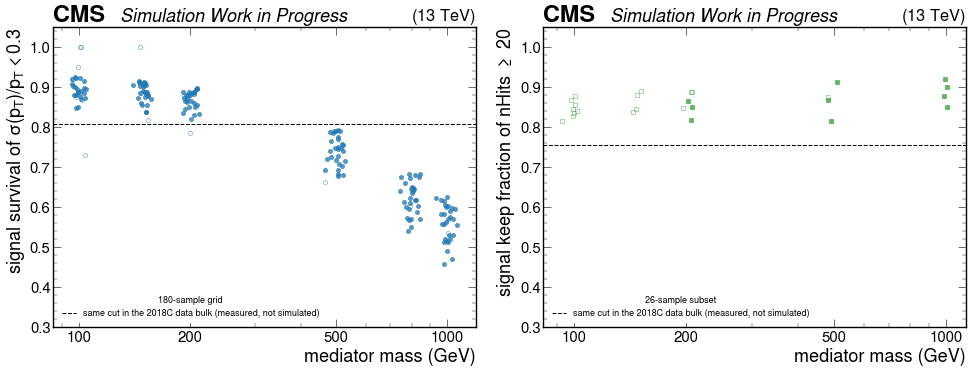

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(20, 8))
jit = lambda a: a * (1 + 0.03 * np.random.default_rng(0).standard_normal(len(a)))

ax = axs[0]
for sel, style in ((robust, dict(marker="o", alpha=0.75)),
                   (~robust, dict(marker="o", markerfacecolor="none", alpha=0.6))):
    ax.plot(jit(S["m"][sel]), S["surv"][sel], linestyle="none", color="tab:blue", **style)
ax.axhline(b_d2[keep_r].sum()/b_d2[1:-1].sum(), color="k", linestyle="--",
           label="same cut in the 2018C data bulk (measured, not simulated)")
ax.set_ylabel(r"signal survival of $\sigma(p_T)/p_T < 0.3$")
titles = ["180-sample grid", "26-sample subset"]

ax = axs[1]
NHR = np.array([r["neff_tail"] >= 200 for r in nh_rows])
ka  = np.array([r["keep_all"] for r in nh_rows])
for sel, style in ((NHR, dict(marker="s", alpha=0.75)),
                   (~NHR, dict(marker="s", markerfacecolor="none", alpha=0.6))):
    ax.plot(jit(NHM[sel]), ka[sel], linestyle="none", color="tab:green", **style)
ax.axhline(b_d[keep_n].sum()/b_d[1:-1].sum(), color="k", linestyle="--",
           label="same cut in the 2018C data bulk (measured, not simulated)")
ax.set_ylabel(r"signal keep fraction of nHits $\geq$ 20")

for ax in axs:
    ax.set_xscale("log")
    ax.set_xlabel("mediator mass (GeV)")
    ax.set_ylim(0.3, 1.05)
    ax.set_xticks([100, 200, 500, 1000])
    ax.set_xticklabels(["100", "200", "500", "1000"])
    ax.legend(fontsize=13, loc="lower left", title=titles.pop(0), title_fontsize=13,
              frameon=True, facecolor="white", edgecolor="none", framealpha=0.92)
    hep.cms.label(data=False, text="Work in Progress", ax=ax)
plt.tight_layout()
plt.show()
plt.close()

### 9.1 `nHits >= 20`

The most effective of the three on the ratio, and the one with the clearest cost. It takes the
post-veto tail data/MC from 2.385 +/- 0.43 to 1.605 +/- 0.33, because it removes 40.8% of the
data tail and only 12% of the MC tail. It does not remove the discrepancy; it halves it.

The cost is that it is a cut on a variable data and MC disagree about at the 15-sigma level in
the bulk, which is precisely the caveat of section 6. It removes 24.5% of the data bulk against
14.1% of the MC bulk, so adopting it would require a scale factor to be measured and carried,
not just the cut. On signal it costs about 15%: pooled over the 26-sample subset it
keeps 0.854 of the signal DSA muons at all pT and 0.850 below 200 GeV. It is cheaper on the
signal muons that land in the tail, 0.92, an 8% cost - but only 6.75% of signal DSA muons are
in that tail, so 15% is the number that matters and the 8% must never be quoted on its own. The keep fraction rises gently with mediator mass, 0.845 at 100 GeV to 0.887
at 1 TeV, and is flat in lifetime, so it needs no lifetime-dependent modelling. Applied after
the Spread veto its marginal keep is 0.869; the two cuts are very nearly independent on signal
(the exact AND exceeds the naive product of the two efficiencies by 1.5%).

### 9.2 `sigma(pT)/pT < 0.3`

The most aggressive of the three, and the least useful. It removes 92% of the post-veto data
tail while costing 19% of the bulk - but it keeps 0.145 of the MC tail against 0.084 of the
data tail, i.e. it cuts *harder* on data than on MC, so it moves the ratio in the wrong
direction. Its real cost is on signal: the survival averaged over the robust grid is 0.752,
and it is driven almost entirely by mediator mass, 0.892 at 100 GeV falling to 0.560 at 1 TeV,
where the muons are stiffest and their fractional momentum error largest. It is essentially
independent of the Spread veto (the exact AND and the naive product differ by less than 2%).
Paying 45% of the signal at the high-mass end to remove a tail one is not going to cut on
anyway is not a good trade.

### 9.3 The DSA-PF control as a data-driven correction

The third option is not a cut. Section 8 measures the DSA momentum mismeasurement rate in data
and in MC on an independent, matched sample, so it can be used to *size* a correction or an
uncertainty on the DSA high-pT rate rather than to remove events. That is the option most
compatible with the analysis, since it costs no signal at all.

Its limitation is the non-flatness: the `P(r > 2)` ratio varies by a factor 2 across `|eta|`
(chi2 69.8/4) and by 1.7 across nHits (chi2 45.5/6), so a single global factor would carry a
large systematic and a binned correction would need more control statistics than one era of
`DoubleMuon` provides.

### 9.4 What is missing to go further

Three histograms would settle the questions left open above, and none of them is expensive:

- **`phi` x `nHits`** in the tail. This is the important one. It would say directly whether the
  126 low-nHits survivors carry a cosmic vertical excess, which the inclusive limit of
  section 7 cannot exclude at the 15% level within that subset.
- **`|eta|` x `nHits`** (or a three-dimensional `pT` x `|eta|` x `nHits`). The inclusion-exclusion
  bound of section 6 shows at least 17% of the excess must be simultaneously endcap and
  low-nHits, but the overlap itself is not measurable from the two one-dimensional splits.
- **`mu_lj_dsaMuon_pt_nHits` on the full 180-sample signal grid**, so the signal cost of a
  hit-count cut rests on the whole grid rather than a 26-sample subset chosen for statistics.

## 10. Conclusions

**On the veto comparison.** The vertex veto is an equivalent cosmic tagger and a worse cut. It
flags 98% of the mu-type lepton jets in the spread-inverted cosmic region, which is defined
without any reference to the vertex tables, and after either veto the surviving tail is equally non-cosmic. But it
has no additional data-versus-MC separating power - the data/MC ratio of the lepton jets it
keeps is flat at 0.75 across four decades of threshold, against 0.77 with no cut at all - it
leaves the same residual data/MC above 200 GeV (2.38 against 2.31 on the same background
stack, and 2.39 for the Spread veto on the eight-sample tail set), and it costs about 30% more
signal: per lepton jet it keeps 0.690 of the reference sample against 0.961 for the Spread
veto, averaged over the 162 robust points of the grid. **The Spread veto is the one to keep.**
The vertex fit is worth remembering only in the corner where the ordering reverses -
`m_Zd = 5` GeV, mediator mass 100 to 150 GeV, `ctau >= 130` mm, exactly 8 of 180 samples per
DSA muon - where the max-over-pairs construction of the Spread variables starts failing on
genuinely wide, displaced pairs and the min-over-pairs vertex requirement does not.

**On the tail.** The spread + cosAlpha veto removes 87% of the >= 200 GeV DSA-muon tail in
2018C data (2414 -> 309). In MC it removes 55% of the **full background stack's** tail
(293.6 -> 133.7) and 3% of the **eight-sample tail set's** (133.7 -> 129.5); the two describe
different MC sets and neither number travels without its label. The removed component is
unambiguously cosmic: the pre-veto tail has a vertical/horizontal `phi` ratio of 12.2 +/- 1.3
against an MC expectation of 1.3 +/- 0.2, and is 93% barrel against 71% in MC. Two independent
routes put its cosmic content at 87% (veto retention measured against the MC prompt-muon
reference) and 84% (the two-template `phi` fit). What survives is not cosmic - the post-veto
tail `phi` ratio is 0.94 +/- 0.15, consistent with MC and incompatible with the cosmic
template, bounding any residual cosmic contribution below 6% of the tail at 95% CL, a bound
that moves only to 7.8% even if the template's vertical fraction is degraded from 0.99 to 0.90.

The surviving tail exceeds MC by 2.4 +/- 0.4, and that ratio is deliberately not the
load-bearing number: its denominator sits in a control region where MC carries 38% more DSA
muons per mu-type lepton jet than data (section 3.1), and no scale factor is applied anywhere.
The statement that does carry is a ratio of rates, which is immune to that mismatch. In an
independent DSA-PF matched control, data over-produces >= 200 GeV DSA muons from < 100 GeV PF
muons by 3.47 +/- 0.25 relative to MC; dividing the post-veto tail rate by that feed-up rate
gives **0.95 +/- 0.06 in data and 0.99 +/- 0.18 in MC**, both consistent with one, against
4.81 +/- 0.13 for data before the veto. This is a consistency statement of about factor-1.5
precision, not a demonstration that the two agree: the control rate is measured pre-veto on a
different (matched, `pT_PF < 100` GeV) population, the mismodelling is not flat in `|eta|` or
nHits, and the closure moves between 0.70 and 1.41 in data and between 0.57 and 1.35 in MC as
the `pT_PF` threshold moves. Whether the 126 low-nHits survivors are part of that feed-up or a
distinct population remains open; resolving it needs a `phi` x `nHits` histogram.

**Three things that are easy to over-read and should not be.**

1. The post-veto tail *looks* concentrated at low hit count (shape chi2 37.5/3), but the bulk
   carries the same distortion at 15 sigma - data has 1.5 to 1.7 times more low-nHits DSA
   muons than MC everywhere. Dividing it out leaves a tail-specific effect of 1.95 +/- 0.46,
   2.1 sigma, and even that denominator is measured on an MC set covering half the stack. The
   chi2 itself is diagonal-only and moves by a factor of about four with the definition of the
   test (17.7/3, 39.7/3 or 75.3/3 on the same four bins), which is why the 1.95 +/- 0.46, and
   not a chi2, is quoted as the result. The `|eta|` structure is different: it *is*
   tail-specific (bulk chi2 1.6/2 against tail 238.5/2) and it is the cosmic fingerprint.
2. The MC tail rests on an effective 35 events, two samples of which contribute single
   weighted events. Every MC-normalized number here inherits that - the +/- 0.4 on the 2.4 and
   the +/- 0.18 on the MC closure alike - which is why "in simulation the tail is resolution
   feed-up and nothing else" is a claim this study cannot make at 18% precision.
3. The vertex-inverted cosmic region used as the `phi` template is 94% high-hit-count, but it
   selects
   on a back-to-back muon pair, and cosAlpha is exactly what a short track reconstructs worst.
   It therefore gives no evidence that the low-nHits survivors are cosmic, and none that they
   are not; the inclusive 6% bound still allows a residual reaching ~15% of that 126-event
   subset.

**Recommendation.** Keep the Spread veto with the cosAlpha cut. Treat the residual DSA high-pT
rate with a data-driven correction sized on the DSA-PF control sample of section 8, carrying
its `|eta|` and nHits non-flatness as the systematic, rather than by adding an object-level
cut: `nHits >= 20` halves the discrepancy but costs 15% of the signal DSA muons at all pT (8%
of those already in the tail, a number that must not be quoted on its own since only 6.75% of
signal DSA muons are there) and is itself a 15-sigma-mismodelled variable that would need its
own scale factor; `sigma(pT)/pT < 0.3` moves the ratio the wrong way while costing 45% of the
signal at high mediator mass. Book the `phi` x `nHits` histogram in the next
data pass. The vertex-fit code, its channels and its histograms stay in the repository as a
documented negative result: the variable is validated and behaves as specified, and outside one
corner of the signal grid it is not useful here.

In [31]:
print("Summary numbers quoted in the conclusions, recomputed:")
print(f"  control-region normalization (Before): {lj_d/lj_m:.3f} per mu-type LJ, "
      f"{ds_d/ds_m:.3f} per DSA muon; MC carries "
      f"{100*((ds_m/lj_m)/(ds_d/lj_d) - 1):.0f}% more DSA muons per LJ")
print(f"  spread-inverted cosmic LJs failing 0 <= vtx_chi2 < 5 : "
      f"{1 - kept(v_cos, 5)/v_cos.sum():.3f}")
print(f"  data/MC of the LJs the vertex veto keeps, thresholds 2 to 1e4: "
      f"{dmc_kept.min():.3f} to {dmc_kept.max():.3f} (no cut {tot_d/tot_m:.3f})")
print(f"  signal efficiency per LJ, robust subset: Spread "
      f"{S['lj_sp'][robust].mean():.4f}, vertex fit {S['lj_vt'][robust].mean():.4f}")
print(f"  samples where vtx beats Spread: {int((S['dsa_vt'] > S['dsa_sp']).sum())} per DSA "
      f"muon, {int((S['lj_vt'] > S['lj_sp']).sum())} per LJ, of {len(sig_names)}")
print(f"  tail yields: data {lj['Before']['d_tail']:.0f} -> "
      f"{lj['Spread+cosAlpha']['d_tail']:.0f} "
      f"({100*(1 - lj['Spread+cosAlpha']['d_tail']/lj['Before']['d_tail']):.0f}% removed);  "
      f"MC, 8-sample tail set {lj['Before']['m_tail']:.1f} -> "
      f"{lj['Spread+cosAlpha']['m_tail']:.1f} "
      f"({100*(1 - lj['Spread+cosAlpha']['m_tail']/lj['Before']['m_tail']):.0f}% removed)")
_fsb = sum(tot(s, CH_BEFORE, 200, scale=ratio) for s in summed_MC)
_fss = sum(tot(s, CH_SPREAD, 200, scale=ratio) for s in summed_MC)
print(f"    the same MC tail on the FULL stack: {_fsb:.1f} -> {_fss:.1f} "
      f"({100*(1 - _fss/_fsb):.0f}% removed) - different set, different number")
print(f"  post-veto tail data/MC  : {meas:.3f} +/- {e_meas:.3f} (8-sample tail set); "
      f"{lj['Spread+cosAlpha']['d_tail']/_fss:.2f} on the full stack")
print(f"  phi V/H, tail           : Before {phi_res[('Before','tail')][0]:.2f} "
      f"+/- {phi_res[('Before','tail')][1]:.2f}  ->  Spread+cosAlpha "
      f"{phi_res[('Spread+cosAlpha','tail')][0]:.2f} "
      f"+/- {phi_res[('Spread+cosAlpha','tail')][1]:.2f}  "
      f"(MC {phi_res[('Spread+cosAlpha','tail')][2]:.2f} "
      f"+/- {phi_res[('Spread+cosAlpha','tail')][3]:.2f}, cosmic template "
      f"{phi_res[('vertex-inverted cosmic','tail')][0]:.1f})")
print(f"  residual cosmic fraction: < {f_ul:.3f} at 95% CL "
      f"(< {f_ul*d_tail:.0f} of {d_tail:.0f} events)")
print(f"  feed-up data/MC         : {FU['ratio']:.3f} +/- {FU['e_ratio']:.3f}")
print(f"  rate closure (tail rate / feed-up rate), post-veto: "
      f"data {CLOS[('Spread+cosAlpha','data')][0]:.3f} "
      f"+/- {CLOS[('Spread+cosAlpha','data')][1]:.3f}, "
      f"MC {CLOS[('Spread+cosAlpha','MC')][0]:.3f} "
      f"+/- {CLOS[('Spread+cosAlpha','MC')][1]:.3f}")
print(f"    pre-veto: data {CLOS[('Before','data')][0]:.2f} "
      f"+/- {CLOS[('Before','data')][1]:.2f}, "
      f"MC {CLOS[('Before','MC')][0]:.2f} +/- {CLOS[('Before','MC')][1]:.2f}")
print(f"  nHits >= 20 signal cost : {1 - wavg('keep_all'):.3f} of signal DSA muons at all pT, "
      f"{1 - np.nansum(kt * wt) / wt[np.isfinite(kt)].sum():.3f} of those in the tail")
print(f"  P(r>2) data/MC {RESP[2.0][0]:.3f} +/- {RESP[2.0][1]:.3f}, "
      f"P(r>5) {RESP[5.0][0]:.3f} +/- {RESP[5.0][1]:.3f}; "
      f"flatness chi2 |eta| {FLAT['|eta|'][1]:.1f}/{FLAT['|eta|'][2]}, "
      f"nHits {FLAT['nHits'][1]:.1f}/{FLAT['nHits'][2]}")
c2t_n = DR[("nHits", "Spread+cosAlpha")][2]
c2b_n = DR[("nHits", "Spread+cosAlpha")][3]
dr_lo = DR[("nHits", "Spread+cosAlpha")][0][0]
db_lo = DR[("nHits", "Spread+cosAlpha")][1][0]
tb    = dr_lo[3] / db_lo[3]
etb   = tb * math.sqrt((dr_lo[4]/dr_lo[3]) ** 2 + (db_lo[4]/db_lo[3]) ** 2)
print(f"  nHits shape chi2        : tail {c2t_n:.1f}/3, bulk {c2b_n:.0f}/3; "
      f"low-nHits tail/bulk {tb:.2f} +/- {etb:.2f} ({abs(tb-1)/etb:.1f} sigma)")
print(f"  |eta| shape chi2 (Before): tail {DR[('|eta|','Before')][2]:.1f}/2, "
      f"bulk {DR[('|eta|','Before')][3]:.1f}/2")

Summary numbers quoted in the conclusions, recomputed:
  control-region normalization (Before): 0.770 per mu-type LJ, 0.556 per DSA muon; MC carries 38% more DSA muons per LJ
  spread-inverted cosmic LJs failing 0 <= vtx_chi2 < 5 : 0.980
  data/MC of the LJs the vertex veto keeps, thresholds 2 to 1e4: 0.747 to 0.758 (no cut 0.770)
  signal efficiency per LJ, robust subset: Spread 0.9608, vertex fit 0.6897
  samples where vtx beats Spread: 8 per DSA muon, 6 per LJ, of 180
  tail yields: data 2414 -> 309 (87% removed);  MC, 8-sample tail set 133.7 -> 129.5 (3% removed)
    the same MC tail on the FULL stack: 293.6 -> 133.7 (54% removed) - different set, different number
  post-veto tail data/MC  : 2.385 +/- 0.426 (8-sample tail set); 2.31 on the full stack
  phi V/H, tail           : Before 12.23 +/- 1.29  ->  Spread+cosAlpha 0.94 +/- 0.15  (MC 1.23 +/- 0.21, cosmic template 107.6)
  residual cosmic fraction: < 0.062 at 95% CL (< 19 of 309 events)
  feed-up data/MC         : 3.474 +/- 0.